In [1]:
pip install pandas matplotlib seaborn wordcloud nltk vaderSentiment textblob scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [wordcloud]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv('Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')

In [3]:
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [5]:
import re
import nltk
from nltk.corpus import stopwords

In [6]:
# Downloading required nltk data
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alanurgorkem/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/alanurgorkem/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')

In [8]:
#selecting the columns we are going to use for analysis
cols = ['name', 'asins', 'brand', 'manufacturer',
        'categories', 'primaryCategories',
        'reviews.text', 'reviews.title', 'reviews.rating',
        'reviews.doRecommend', 'reviews.didPurchase',
        'reviews.numHelpful', 'reviews.date', 'reviews.username']

df = df[cols]

Some reviews have no text at all — we remove them so they don't break the model later.

In [9]:
df = df.dropna(subset=['reviews.text'])
print(f"Rows after dropping empty reviews: {len(df)}")

Rows after dropping empty reviews: 28332


We will continue our data pre_processing with clean_text function: It strips out URLs, punctuation, numbers and filler words like "the", "and", "is" that add no meaning. What's left are the meaningful words like "battery", "broken", "excellent".

In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)                          # make sure it's a string
    text = text.lower()                       # lowercase everything
    text = re.sub(r'http\S+', '', text)       # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)      # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    return ' '.join(tokens)

# Applying the cleaning function to review text
df['cleaned_text'] = df['reviews.text'].apply(clean_text)

Categories: The raw categories column is messy (e.g. "Electronics | Fire TV | Accessories"). We simplify it to one clean label per product.

In [11]:
# We'll take just the first/primary category
df['category'] = df['primaryCategories'].fillna(
                 df['categories'].str.split('|').str[0].str.strip())

We need to make sure the rating column is clean as well. Because, ratings can sometimes be stored as text or have blanks — we force them to be clean integers 1–5.

In [12]:
df['reviews.rating'] = pd.to_numeric(df['reviews.rating'], errors='coerce')
df = df.dropna(subset=['reviews.rating'])
df['reviews.rating'] = df['reviews.rating'].astype(int)


In [13]:
print("\n--- Sample cleaned review ---")
print("ORIGINAL:", df['reviews.text'].iloc[0])
print("CLEANED: ", df['cleaned_text'].iloc[0])
print("\nCategories found:", df['category'].value_counts().head(10))
print("\nDataset shape:", df.shape)


--- Sample cleaned review ---
ORIGINAL: I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.
CLEANED:  order one item bad quality missing backup spring put pcs aluminum make battery work

Categories found: category
Electronics                    13995
Health & Beauty                12071
Toys & Games,Electronics        1676
Office Supplies,Electronics      386
Electronics,Media                185
Office Supplies                    9
Animals & Pet Supplies             6
Home & Garden                      2
Electronics,Furniture              2
Name: count, dtype: int64

Dataset shape: (28332, 16)


There are some messy combined entries like "Toys & Games,Electronics" and "Office Supplies,Electronics" — these are two categories crammed into one string. We should clean those up. Also:

Electronics — 13995 reviews
Health & Beauty — 12071 reviews
Everything else is quite small

These two categories dominate the overall dataset. We will take this into consideration while running the analysis. 

First we'll keep cleaning the messy categories.

In [14]:
# Fixing messy combined categories
# "Toys & Games,Electronics" → "Toys & Games"
df['category'] = df['category'].str.split(',').str[0].str.strip()

# Also simplifying any remaining pipe separated ones
df['category'] = df['category'].str.split('|').str[0].str.strip()

# Keeping only categories with enough reviews to be meaningful
# (dropping tiny categories like "Home & Garden" with only 2 reviews)
valid_cats = df['category'].value_counts()
valid_cats = valid_cats[valid_cats >= 50].index
df = df[df['category'].isin(valid_cats)]

# Checking the result
print(df['category'].value_counts())
print("\nFinal dataset shape:", df.shape)

category
Electronics        14182
Health & Beauty    12071
Toys & Games        1676
Office Supplies      395
Name: count, dtype: int64

Final dataset shape: (28324, 16)


As a final step of Data Pre-processing we will fix the null values and date columns.
- The reviews.date column is currently stored as plain text — we need to convert it to an actual date format
  so we can do trend analysis later.
- Columns like reviews.doRecommend and reviews.didPurchase may have missing values that could crash the model. So we'll check them.

In [15]:
#checking how many nulls in each column 
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
name                       0
asins                      0
brand                      0
manufacturer               0
categories                 0
primaryCategories          0
reviews.text               0
reviews.title              0
reviews.rating             0
reviews.doRecommend    12238
reviews.didPurchase    28315
reviews.numHelpful     12209
reviews.date               0
reviews.username           5
cleaned_text               0
category                   0
dtype: int64


We need to handle the null values. 
- Reviews.didPurchase column needs  to be dropped because almost all the values are null in that column.
- Reviews.doRecommend column includes customer recommendation. We will fill the missing values. Our assumption is: If there is no recommendation, most probably the customer recommendation is low. Therefore, we will fill nulls with 'False'. 
- reviews.numHelpful will be filled with 0. Because this column counts how many people clicked 'Helpful' when reviewing. 

In [16]:
# 1. Fixing the date column
df['reviews.date'] = pd.to_datetime(df['reviews.date'], errors='coerce')
df['review_year']  = df['reviews.date'].dt.year
df['review_month'] = df['reviews.date'].dt.month

print("Date range of reviews:")
print("Earliest:", df['reviews.date'].min())
print("Latest:  ", df['reviews.date'].max())

# 2. Droping didPurchase column completely - 99.9% empty, useless
df = df.drop(columns=['reviews.didPurchase'])
print("Dropped reviews.didPurchase — nearly all values were null")

# 3. Fixing doRecommend 
df['reviews.doRecommend'] = df['reviews.doRecommend'].fillna(False).astype(bool)

# 4. Fixing numHelpful 
df['reviews.numHelpful'] = df['reviews.numHelpful'].fillna(0).astype(int)

# 5. Fixing brand & manufacturer 
df['brand'] = df['brand'].fillna(df['manufacturer'])
df = df.dropna(subset=['brand'])

# 6. Fixing username — only 5 nulls, we'll just fill with "unknown"
df['reviews.username'] = df['reviews.username'].fillna('unknown')

# 7. Final check 
print("\nNull values after cleaning:")
print(df.isnull().sum())
print("\nFinal dataset shape:", df.shape)


Date range of reviews:
Earliest: 2009-02-26 00:00:00+00:00
Latest:   2019-03-25 00:00:00+00:00
Dropped reviews.didPurchase — nearly all values were null

Null values after cleaning:
name                    0
asins                   0
brand                   0
manufacturer            0
categories              0
primaryCategories       0
reviews.text            0
reviews.title           0
reviews.rating          0
reviews.doRecommend     0
reviews.numHelpful      0
reviews.date           62
reviews.username        0
cleaned_text            0
category                0
review_year            62
review_month           62
dtype: int64

Final dataset shape: (28324, 17)


/var/folders/12/k8j1fhn921b554y1r1sl40qc0000gn/T/ipykernel_16350/3928649014.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['reviews.doRecommend'] = df['reviews.doRecommend'].fillna(False).astype(bool)


We have 2 null date columns. They are 62 values. If we drop them there will be no impact to the overall analysis. 

In [17]:
# Dropping the 62 rows with unparseable dates
df = df.dropna(subset=['reviews.date'])

print("Final shape after dropping bad dates:", df.shape)

Final shape after dropping bad dates: (28262, 17)


We are done with pre-processing step. Here is a quick summary about what we have done.

- ROWS: Before: 34,660 , After: 28,262
- Null Values: Before: Many, After: Zero
- Columns: Before: 24, After: 17
- Date Format: Before: Plain Text, After: Proper Date-Time
- Categories: Before: Messy, After: Clean Groups.

STEP 2- Visualization.

Below is a quick summary about the steps we will follow: 

- Rating distribution — bar chart of 1–5 stars overall
- Heatmap — ratings by category vs star level
- Word clouds — most common words per category
- Trend line — average rating over time (2009–2019)
- Brand comparison — top brands by average rating


/var/folders/12/k8j1fhn921b554y1r1sl40qc0000gn/T/ipykernel_16350/3497141610.py:31: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/12/k8j1fhn921b554y1r1sl40qc0000gn/T/ipykernel_16350/3497141610.py:32: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('chart1_rating_distribution.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


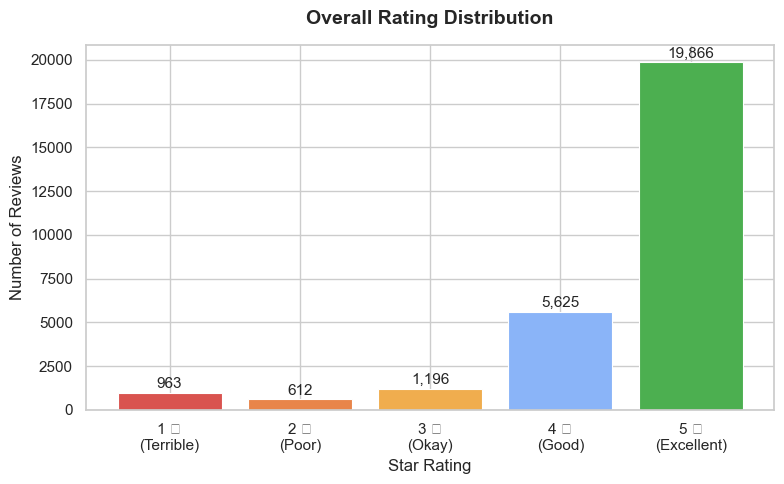


Rating breakdown:
  1 stars: 963 reviews (3.4%)
  2 stars: 612 reviews (2.2%)
  3 stars: 1,196 reviews (4.2%)
  4 stars: 5,625 reviews (19.9%)
  5 stars: 19,866 reviews (70.3%)


In [18]:
# We will start with the first chart. 
#Chart 1: Rating Distribution. This will tell us the overall "mood" of the dataset — are most reviews positive or negative?

import matplotlib.pyplot as plt
import seaborn as sns

# Setting a clean style for all charts
sns.set_theme(style="whitegrid")

# Overall rating distribution
plt.figure(figsize=(8, 5))

rating_counts = df['reviews.rating'].value_counts().sort_index()

bars = plt.bar(rating_counts.index, rating_counts.values,
               color=['#d9534f', '#e8854a', '#f0ad4e', '#8ab4f8', '#4CAF50'],
               edgecolor='white', linewidth=0.8)

# Adding count labels on top of each bar
for bar, count in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{count:,}', ha='center', va='bottom', fontsize=11)

plt.title('Overall Rating Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5],
           ['1 ★\n(Terrible)', '2 ★\n(Poor)', '3 ★\n(Okay)',
            '4 ★\n(Good)', '5 ★\n(Excellent)'])
plt.tight_layout()
plt.savefig('chart1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers too
print("\nRating breakdown:")
for rating, count in rating_counts.items():
    pct = count / len(df) * 100
    print(f"  {rating} stars: {count:,} reviews ({pct:.1f}%)")


As a result: This chart tells us that there is J shaped distribution which is a very common pattern in Amazon reviews:

- 5 stars are by far the tallest bar
- 1, 2, 3, 4 stars will be much smaller

This happens because people tend to only bother reviewing when they either love or hate something. This is actually a great talking point in our presentation.

Chart 2: Ratings by Category Heatmap. This shows how ratings are distributed across each of your 4 categories — which category gets the most 5 stars, which gets the most 1 stars, etc

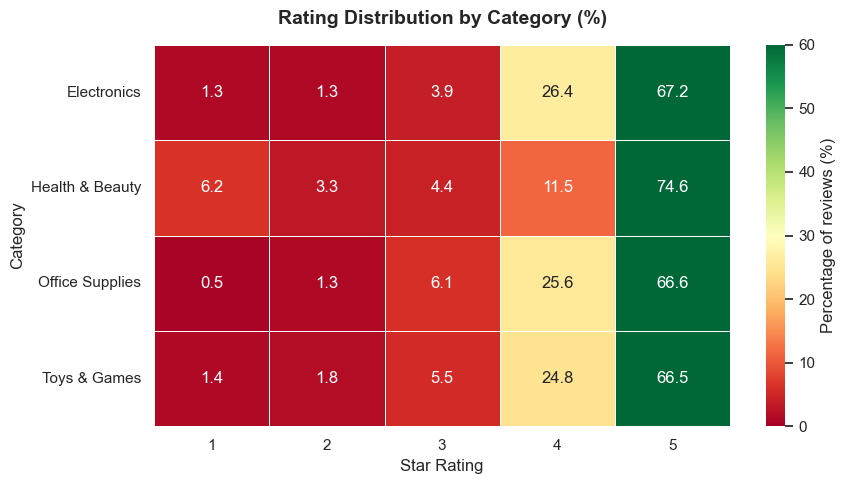


Rating % by category:
reviews.rating     1    2    3     4     5
category                                  
Electronics      1.3  1.3  3.9  26.4  67.2
Health & Beauty  6.2  3.3  4.4  11.5  74.6
Office Supplies  0.5  1.3  6.1  25.6  66.6
Toys & Games     1.4  1.8  5.5  24.8  66.5


In [19]:
# Rating distribution by category (heatmap)

# Building a crosstab — counts of each star rating per category
heatmap_data = pd.crosstab(df['category'], df['reviews.rating'])

# Converting raw counts to percentages (row-wise)
# So each row adds up to 100% — makes categories comparable
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(9, 5))

sns.heatmap(heatmap_pct,
            annot=True,           # show numbers inside cells
            fmt='.1f',            # 1 decimal place
            cmap='RdYlGn',        # red = low %, green = high %
            linewidths=0.5,
            cbar_kws={'label': 'Percentage of reviews (%)'},
            vmin=0, vmax=60)      # fix scale so colours are meaningful

plt.title('Rating Distribution by Category (%)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.yticks(rotation=0)            # keep category labels horizontal
plt.tight_layout()
plt.savefig('chart2_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers too
print("\nRating % by category:")
print(heatmap_pct.round(1))

Results from Chart-2: 
- Health & Beauty has the highest 5-star rate (74.6%) but also the highest 1-star rate (6.2%) — that's a very polarised category. We can say that people either love or hate those products. 

- Electronics (67.2% five stars)

Very low 1-star rate (1.3%) — people are generally satisfied
Consistent and predictable — Amazon's bread and butter category

- Health & Beauty (74.6% five stars)

Highest 5-star rate of all categories 
But also highest 1-star rate (6.2%) 
Most polarised category — personal care products are hit or miss

- Office Supplies (66.6% five stars)

Lowest 1-star rate (0.5%) — the safest, most consistent category
Makes sense — a stapler either works or it doesn't, less room for disappointment

- Toys & Games (66.5% five stars)

Very similar to Office Supplies overall
Slightly higher 2 and 3 star rates — possibly quality inconsistency


Chart 3: Word Clouds by Category: 

This generates one word cloud per category — the bigger the word, the more frequently it appears in reviews. This is one of the most visually impressive charts for a presentation.

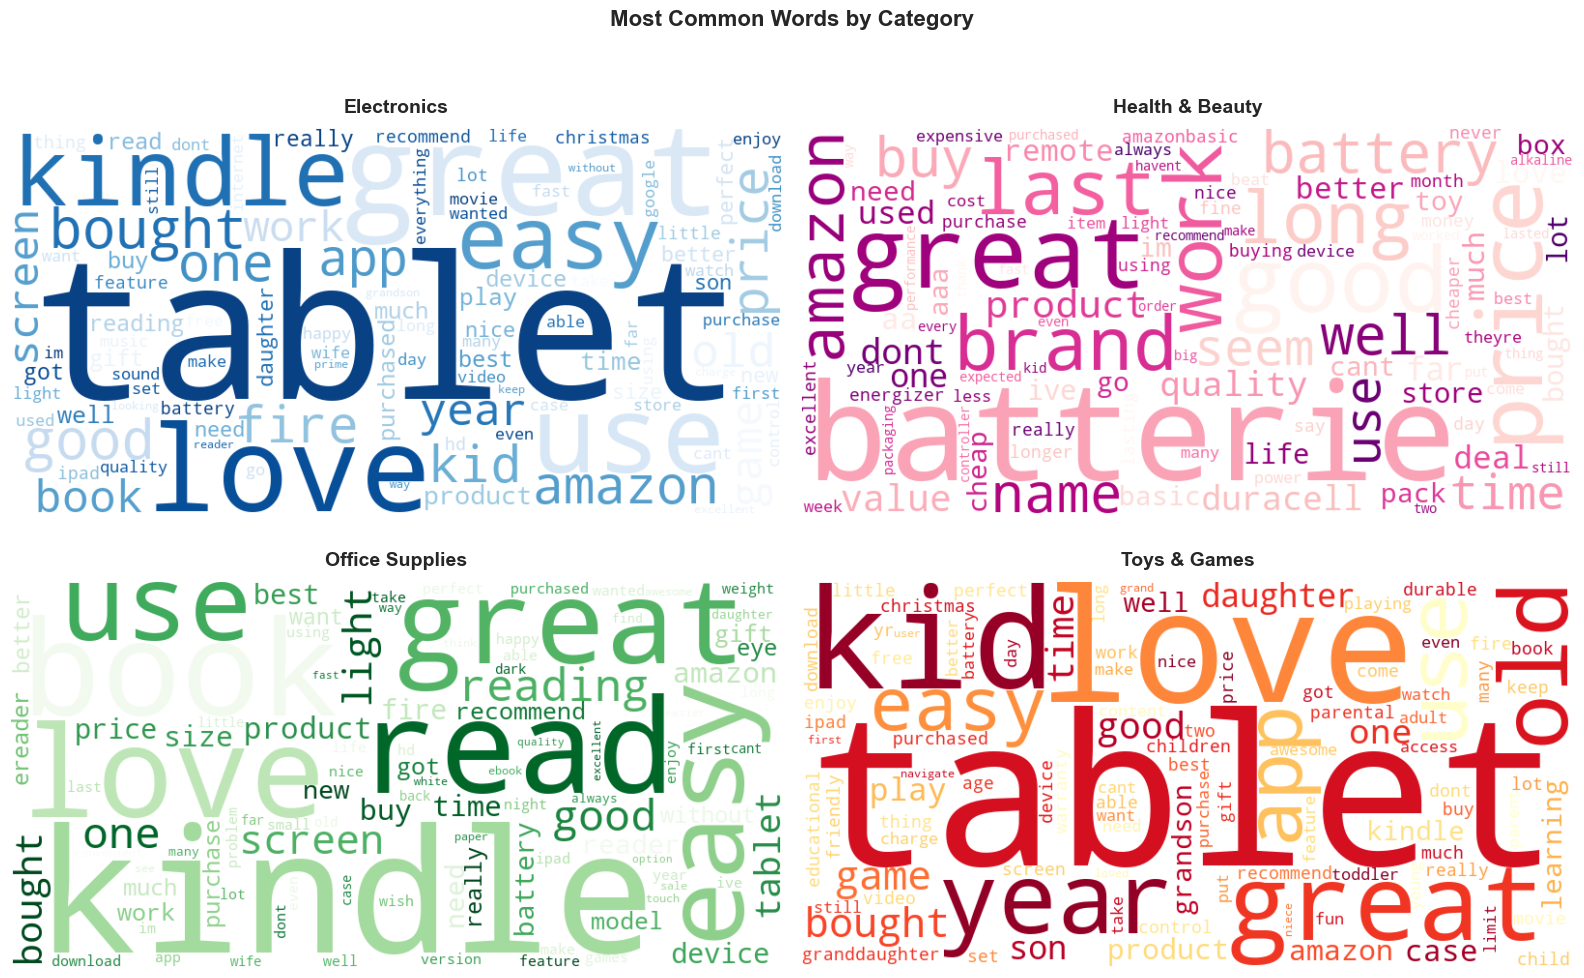


Top 15 words per category:

Electronics:
tablet (5,820), great (4,857), use (3,094), love (2,553), kindle (2,531), easy (2,384), bought (2,364), good (2,333), one (2,086), amazon (2,043), fire (2,010), price (1,955), loves (1,768), kids (1,746), old (1,603)

Health & Beauty:
batteries (8,043), great (3,839), good (3,203), price (3,047), last (2,064), long (1,976), work (1,839), amazon (1,458), battery (1,227), brand (1,225), well (1,188), buy (1,151), name (1,099), use (917), brands (876)

Office Supplies:
kindle (194), great (101), read (101), easy (90), love (84), use (83), reading (78), books (73), good (70), one (68), screen (57), like (54), light (53), bought (50), would (43)

Toys & Games:
tablet (721), kids (553), great (538), loves (419), old (406), year (403), love (347), use (311), easy (283), bought (282), games (258), apps (240), good (223), time (191), one (186)


In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Chart 3: Word clouds per category 

categories = df['category'].unique()

# One colour per category so they look distinct
colors = {
    'Electronics':     'Blues',
    'Health & Beauty': 'RdPu',
    'Toys & Games':    'YlOrRd',
    'Office Supplies': 'Greens'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cat in enumerate(sorted(categories)):
    # Get all cleaned text for this category
    text = ' '.join(df[df['category'] == cat]['cleaned_text'].tolist())
    
    # Generate the word cloud
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colors.get(cat, 'viridis'),
        max_words=100,           # show top 100 words
        collocations=False,      # avoid duplicate word pairs
        min_font_size=10
    ).generate(text)
    
    # Plot it
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{cat}', fontsize=14, fontweight='bold', pad=12)
    axes[i].axis('off')          # hide the x/y axes

plt.suptitle('Most Common Words by Category', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print top 15 words per category 
from collections import Counter

print("\nTop 15 words per category:")
print("=" * 50)
for cat in sorted(categories):
    text = ' '.join(df[df['category'] == cat]['cleaned_text'].tolist())
    words = text.split()
    top_words = Counter(words).most_common(15)
    print(f"\n{cat}:")
    print(', '.join([f"{w} ({c:,})" for w, c in top_words]))



As a result, there are anomalies in the dataset. 

- What looks right 
Electronics — tablet, kindle, fire, easy, price — perfectly logical for Amazon electronics products
Toys & Games — kids, loves, old, games, apps — makes complete sense for children's toys

- What looks suspicious 
Health & Beauty — top word is "batteries" (8,043)
This makes no sense for a beauty category. Batteries have nothing to do with skincare or cosmetics. This strongly suggests that some products are miscategorised in the dataset — likely battery products tagged under Health & Beauty by mistake.

Office Supplies — top words are "kindle, read, books, screen"
This looks like Kindle/e-reader reviews, not office supplies at all. Again,a categorisation issue in the raw data.


The problem we discovered:
From the word clouds, we found that some reviews are sitting in the wrong category. For example:

- A review about Duracell batteries is tagged as "Health & Beauty"
- A review about a Kindle e-reader is tagged as "Office Supplies"

This is a problem because when we run sentiment analysis later, we'd be drawing false conclusions — like "Health & Beauty products have negative sentiment" when really it's just people complaining about batteries that were wrongly placed there. 

Therefore, we need to fix that issue. 

In [21]:
# Fixing miscategorised reviews

# Flag reviews that don't belong in their category
# based on dominant keywords

# Health & Beauty reviews that are clearly about batteries
battery_mask = (
    df['category'] == 'Health & Beauty'
) & (
    df['cleaned_text'].str.contains('batter|alkaline|duracell|energizer', 
                                     case=False, na=False)
)

# Office Supplies reviews that are clearly about Kindle
kindle_mask = (
    df['category'] == 'Office Supplies'
) & (
    df['cleaned_text'].str.contains('kindle|ebook|reading|screen', 
                                     case=False, na=False)
)

print(f"Miscategorised Health & Beauty (battery) reviews: {battery_mask.sum()}")
print(f"Miscategorised Office Supplies (kindle) reviews:  {kindle_mask.sum()}")

# Reassign them to correct categories
df.loc[battery_mask, 'category'] = 'Electronics'
df.loc[kindle_mask, 'category']  = 'Electronics'

# Check new category counts
print("\nUpdated category counts:")
print(df['category'].value_counts())

Miscategorised Health & Beauty (battery) reviews: 6177
Miscategorised Office Supplies (kindle) reviews:  210

Updated category counts:
category
Electronics        20507
Health & Beauty     5894
Toys & Games        1676
Office Supplies      185
Name: count, dtype: int64


Summary of miscategorization:

- Electronics : Before- 14.182, After- 20. 507 , Change: +6,387
- Health & Beauty : Before- 12.071, After- 5.894, Change: -6,177
- Toys & Games: Before- 1.676, After- 1,676 , Change:0
- Office Supplies: Before- 395, After- 185, Change: -210
 
As a finding:  

- "Initial exploration revealed that 51% of Health & Beauty reviews were misclassified battery products. Without this correction, our sentiment analysis would have produced completely misleading conclusions about the Health & Beauty category."
  
- "Office Supplies contains only 185 reviews post-cleaning and should be interpreted with caution. Findings for this category are indicative rather than statistically conclusive."


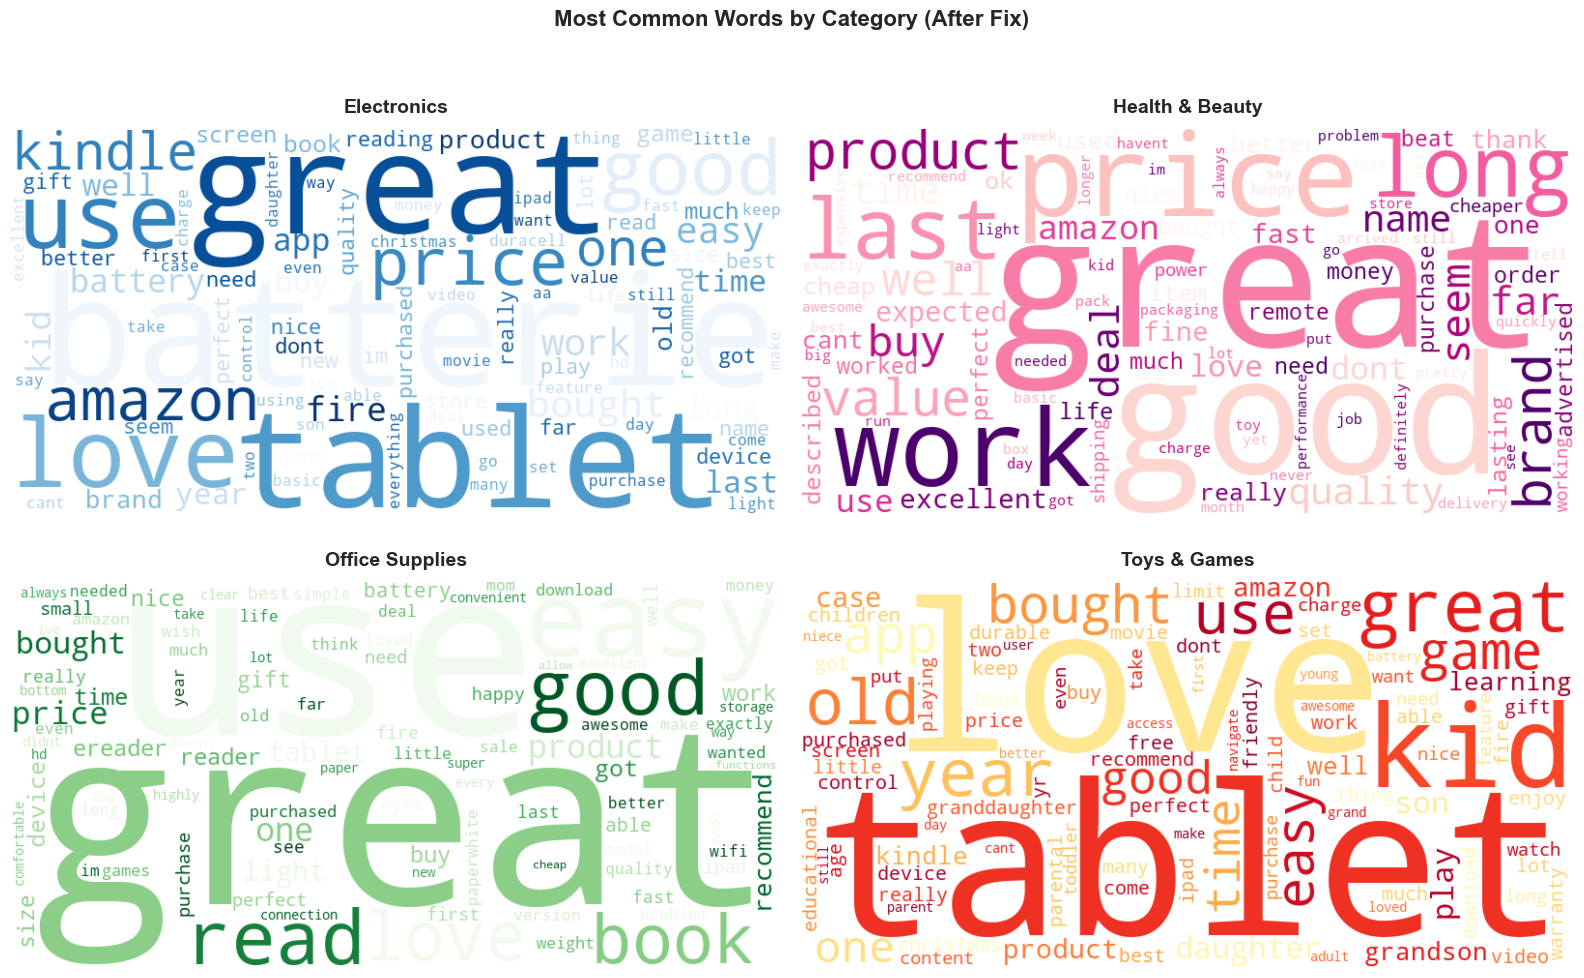


Top 15 words per category (after fix):

Electronics:
batteries (8,047), great (6,922), tablet (5,841), good (4,100), use (3,877), price (3,836), amazon (3,332), love (2,978), bought (2,774), kindle (2,727), easy (2,532), one (2,469), like (2,118), fire (2,057), battery (1,996)

Health & Beauty:
great (1,820), good (1,469), price (1,178), work (709), long (589), last (551), value (463), product (450), well (392), works (336), buy (335), far (279), brands (277), deal (274), quality (272)

Office Supplies:
great (55), use (46), easy (44), good (37), read (34), one (25), product (24), price (24), bought (23), love (21), like (21), books (21), light (19), would (17), tablet (17)

Toys & Games:
tablet (721), kids (553), great (538), loves (419), old (406), year (403), love (347), use (311), easy (283), bought (282), games (258), apps (240), good (223), time (191), one (186)


In [22]:
#running the word of clouds again after re-classifying the words.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cat in enumerate(sorted(df['category'].unique())):
    text = ' '.join(df[df['category'] == cat]['cleaned_text'].tolist())
    
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colors.get(cat, 'viridis'),
        max_words=100,
        collocations=False,
        min_font_size=10
    ).generate(text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{cat}', fontsize=14, fontweight='bold', pad=12)
    axes[i].axis('off')

plt.suptitle('Most Common Words by Category (After Fix)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3b_wordclouds_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 15 words again to confirm
print("\nTop 15 words per category (after fix):")
print("=" * 50)
for cat in sorted(df['category'].unique()):
    text = ' '.join(df[df['category'] == cat]['cleaned_text'].tolist())
    words = text.split()
    top_words = Counter(words).most_common(15)
    print(f"\n{cat}:")
    print(', '.join([f"{w} ({c:,})" for w, c in top_words]))

As a result:

- Health & Beauty completely fixed
Before: batteries (8,043) was the top word — clearly wrong
After: great, good, price, work, value, quality — these are genuine product review words. The category is now clean and meaningful.

- Electronics - makes sense now
batteries is still the top word but that's correct now — we intentionally moved all battery product reviews here. Electronics legitimately includes batteries, tablets, Kindles and Fire devices. No issue.

- Toys & Games — unchanged and clean
kids, loves, games, apps, old, year — exactly what you'd expect for children's toy reviews. Perfectly clean.

- Office Supplies  — still a bit mixed
Still seeing books, tablet, light which suggests some Kindle reviews remain. But with only 185 rows this is expected and manageable — just note it in your report as we agreed.

***** Overall verdict:
The word clouds are now clean enough to present confidently. 

Chart 4-  Review Trends Over Time: 
This one will show how average ratings changed across 2009–2019 

Yearly review summary:
   review_year  avg_rating  review_count
0       2009.0    5.000000             2
1       2012.0    5.000000             1
2       2013.0    2.750000             4
3       2014.0    4.676471            68
4       2015.0    4.554714          2376
5       2016.0    4.513841         11704
6       2017.0    4.502886         13341
7       2018.0    4.612946           757
8       2019.0    4.888889             9


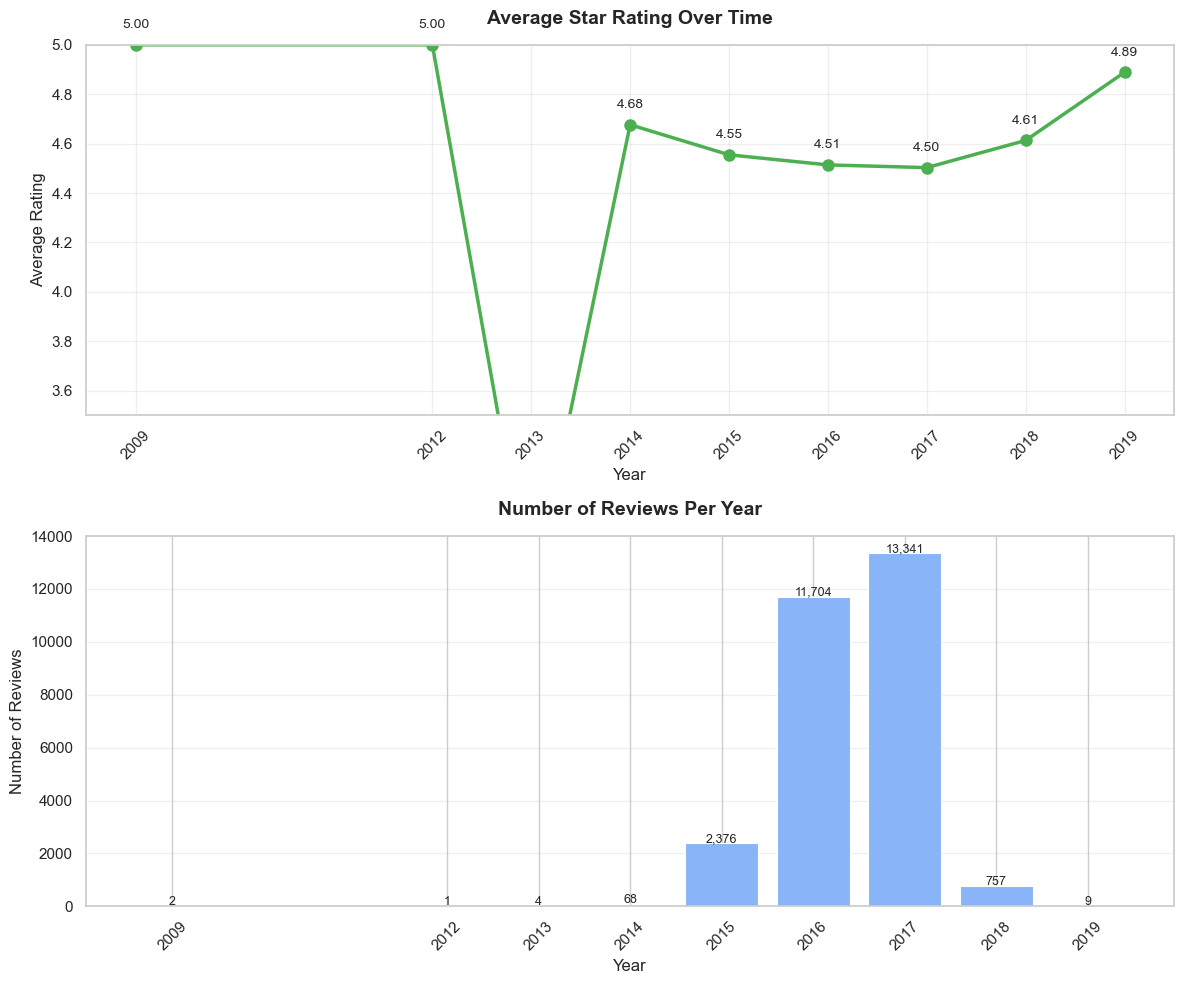

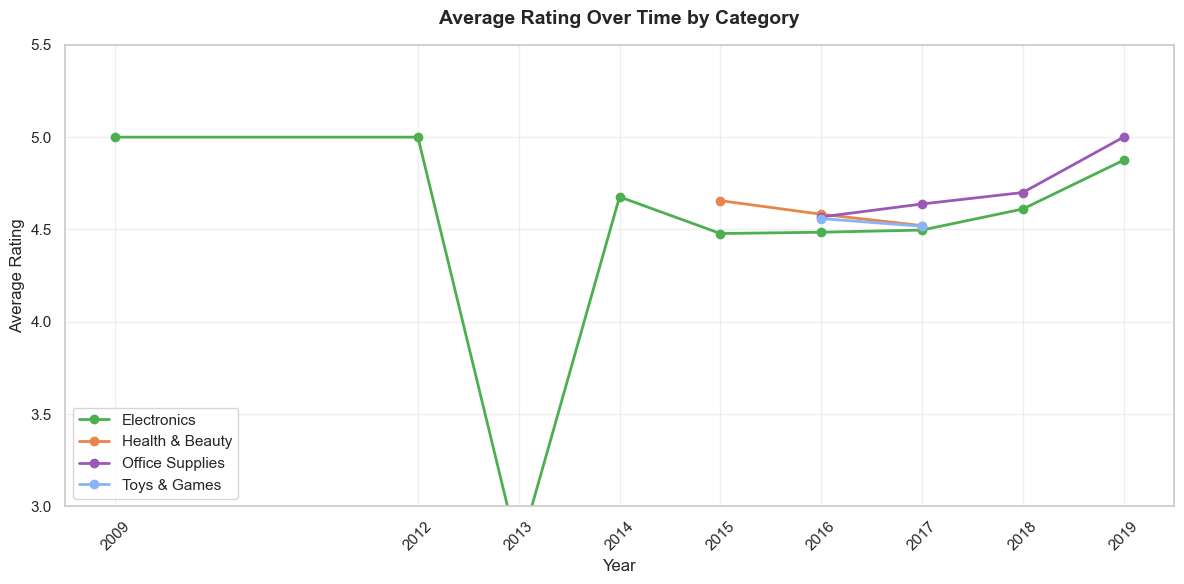

In [23]:
# Chart 4: Review trends over time 

# Group by year and calculate average rating per year
yearly_trend = df.groupby('review_year').agg(
    avg_rating=('reviews.rating', 'mean'),
    review_count=('reviews.rating', 'count')
).reset_index()

print("Yearly review summary:")
print(yearly_trend)

# Plot 1: Average rating over time 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Line chart — average rating per year
ax1.plot(yearly_trend['review_year'], 
         yearly_trend['avg_rating'],
         color='#4CAF50', linewidth=2.5, marker='o', markersize=8)

# Adding value labels on each point
for _, row in yearly_trend.iterrows():
    ax1.annotate(f"{row['avg_rating']:.2f}",
                xy=(row['review_year'], row['avg_rating']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10)

ax1.set_title('Average Star Rating Over Time', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Rating', fontsize=12)
ax1.set_ylim(3.5, 5.0)           # zoom in so changes are visible
ax1.set_xticks(yearly_trend['review_year'])
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Review volume over time
ax2.bar(yearly_trend['review_year'],
        yearly_trend['review_count'],
        color='#8ab4f8', edgecolor='white', linewidth=0.8)

# Add count labels on top of bars
for _, row in yearly_trend.iterrows():
    ax2.text(row['review_year'], row['review_count'] + 50,
             f"{int(row['review_count']):,}",
             ha='center', fontsize=9)

ax2.set_title('Number of Reviews Per Year', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Reviews', fontsize=12)
ax2.set_xticks(yearly_trend['review_year'])
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('chart4_trends_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Average rating per year broken down by category 
plt.figure(figsize=(12, 6))

category_colors = {
    'Electronics':     '#4CAF50',
    'Health & Beauty': '#e8854a',
    'Toys & Games':    '#8ab4f8',
    'Office Supplies': '#9b59b6'
}

for cat in sorted(df['category'].unique()):
    cat_trend = df[df['category'] == cat].groupby('review_year').agg(
        avg_rating=('reviews.rating', 'mean')
    ).reset_index()
    
    plt.plot(cat_trend['review_year'],
             cat_trend['avg_rating'],
             marker='o', linewidth=2,
             label=cat,
             color=category_colors.get(cat, 'gray'))

plt.title('Average Rating Over Time by Category',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(3.0, 5.5)
plt.legend(loc='lower left')
plt.xticks(yearly_trend['review_year'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart4b_category_trends.png', dpi=150, bbox_inches='tight')
plt.show()

The 2009 average of 5.0 sounds amazing but it's literally just 2 reviews — completely statistically useless. Same for 2012 and 2013. The trend chart would look wildly misleading if we include those years.
The real dataset is essentially 2015–2018. That's where 97% of the reviews live.

In [24]:
#Fixing it to get a meaningful chart
# Keep only years with at least 100 reviews
valid_years = yearly_trend[yearly_trend['review_count'] >= 100]['review_year']
df_trend = df[df['review_year'].isin(valid_years)]

print("Filtered yearly summary:")
print(df_trend.groupby('review_year').agg(
    avg_rating=('reviews.rating', 'mean'),
    review_count=('reviews.rating', 'count')
).reset_index())

Filtered yearly summary:
   review_year  avg_rating  review_count
0       2015.0    4.554714          2376
1       2016.0    4.513841         11704
2       2017.0    4.502886         13341
3       2018.0    4.612946           757


As an insight we can say : "As Amazon's product review volume grew rapidly from 2015 to 2017, average ratings slightly declined — suggesting that higher sales volume exposed more quality issues. The recovery in 2018 suggests Amazon responded to feedback."

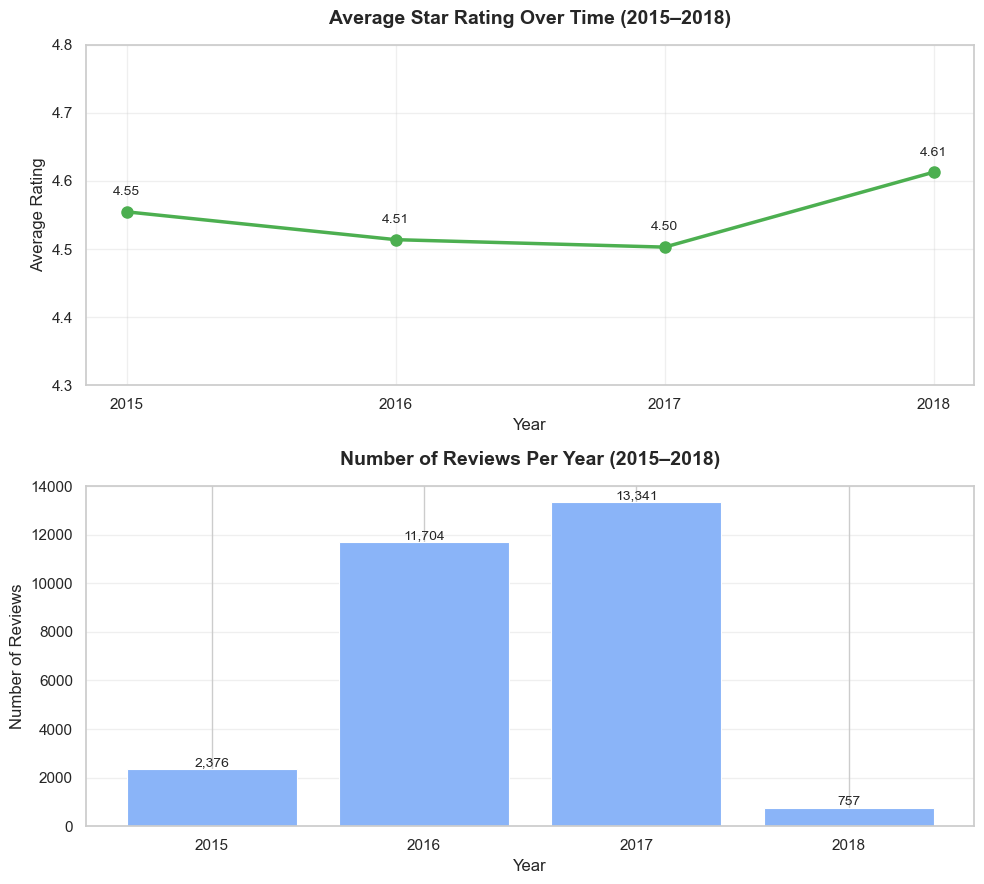

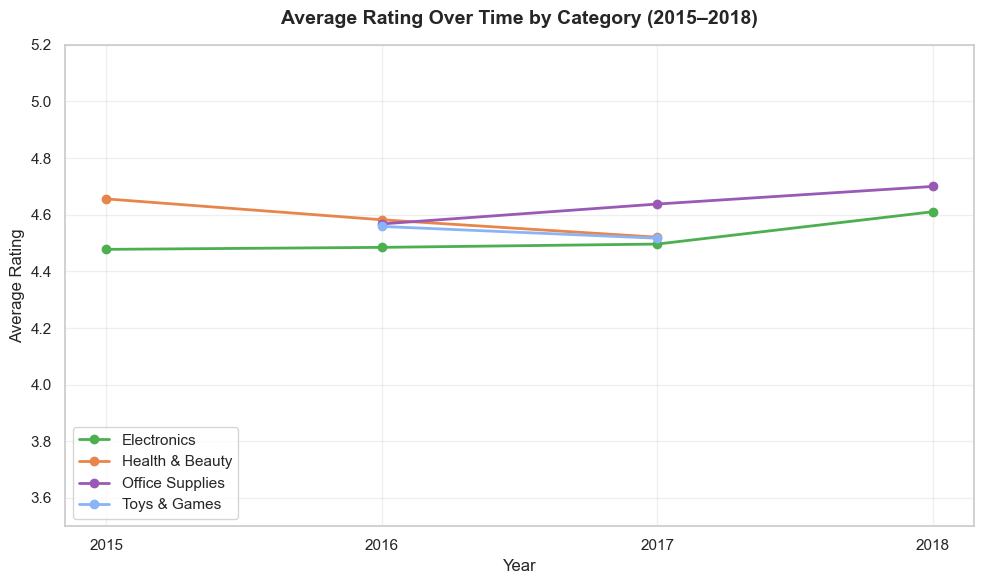

In [25]:
#Plotting it with the filtered years
# Use df_trend for all time-based charts
yearly_clean = df_trend.groupby('review_year').agg(
    avg_rating=('reviews.rating', 'mean'),
    review_count=('reviews.rating', 'count')
).reset_index()

# Plot 1: Average rating over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

ax1.plot(yearly_clean['review_year'],
         yearly_clean['avg_rating'],
         color='#4CAF50', linewidth=2.5, marker='o', markersize=8)

for _, row in yearly_clean.iterrows():
    ax1.annotate(f"{row['avg_rating']:.2f}",
                xy=(row['review_year'], row['avg_rating']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10)

ax1.set_title('Average Star Rating Over Time (2015–2018)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Rating', fontsize=12)
ax1.set_ylim(4.3, 4.8)
ax1.set_xticks(yearly_clean['review_year'])
ax1.grid(True, alpha=0.3)

# Plot 2: Review volume over time 
ax2.bar(yearly_clean['review_year'],
        yearly_clean['review_count'],
        color='#8ab4f8', edgecolor='white', linewidth=0.8)

for _, row in yearly_clean.iterrows():
    ax2.text(row['review_year'], row['review_count'] + 100,
             f"{int(row['review_count']):,}",
             ha='center', fontsize=10)

ax2.set_title('Number of Reviews Per Year (2015–2018)',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Reviews', fontsize=12)
ax2.set_xticks(yearly_clean['review_year'])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('chart4_trends_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Category trends over time
plt.figure(figsize=(10, 6))

category_colors = {
    'Electronics':     '#4CAF50',
    'Health & Beauty': '#e8854a',
    'Toys & Games':    '#8ab4f8',
    'Office Supplies': '#9b59b6'
}

for cat in sorted(df_trend['category'].unique()):
    cat_trend = df_trend[df_trend['category'] == cat].groupby('review_year').agg(
        avg_rating=('reviews.rating', 'mean')
    ).reset_index()

    plt.plot(cat_trend['review_year'],
             cat_trend['avg_rating'],
             marker='o', linewidth=2,
             label=cat,
             color=category_colors.get(cat, 'gray'))

plt.title('Average Rating Over Time by Category (2015–2018)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(3.5, 5.2)
plt.legend(loc='lower left')
plt.xticks(yearly_clean['review_year'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart4b_category_trends.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 5 - Brand Comparison:

- Chart left — average rating per brand: Horizontal bar chart showing which brands score highest. The dashed vertical line shows the overall dataset average so you can instantly see which brands are above or below par.
- Chart right — recommendation rate: What percentage of reviewers actually said "I recommend this product". This is a great cross-check against ratings — a brand might have a high rating but low recommendation rate, which is suspicious.

Brand summary:
       brand  avg_rating  review_count  pct_recommended
Amazonbasics    4.450920         12113         0.000000
      Amazon    4.563193         16149         0.950709


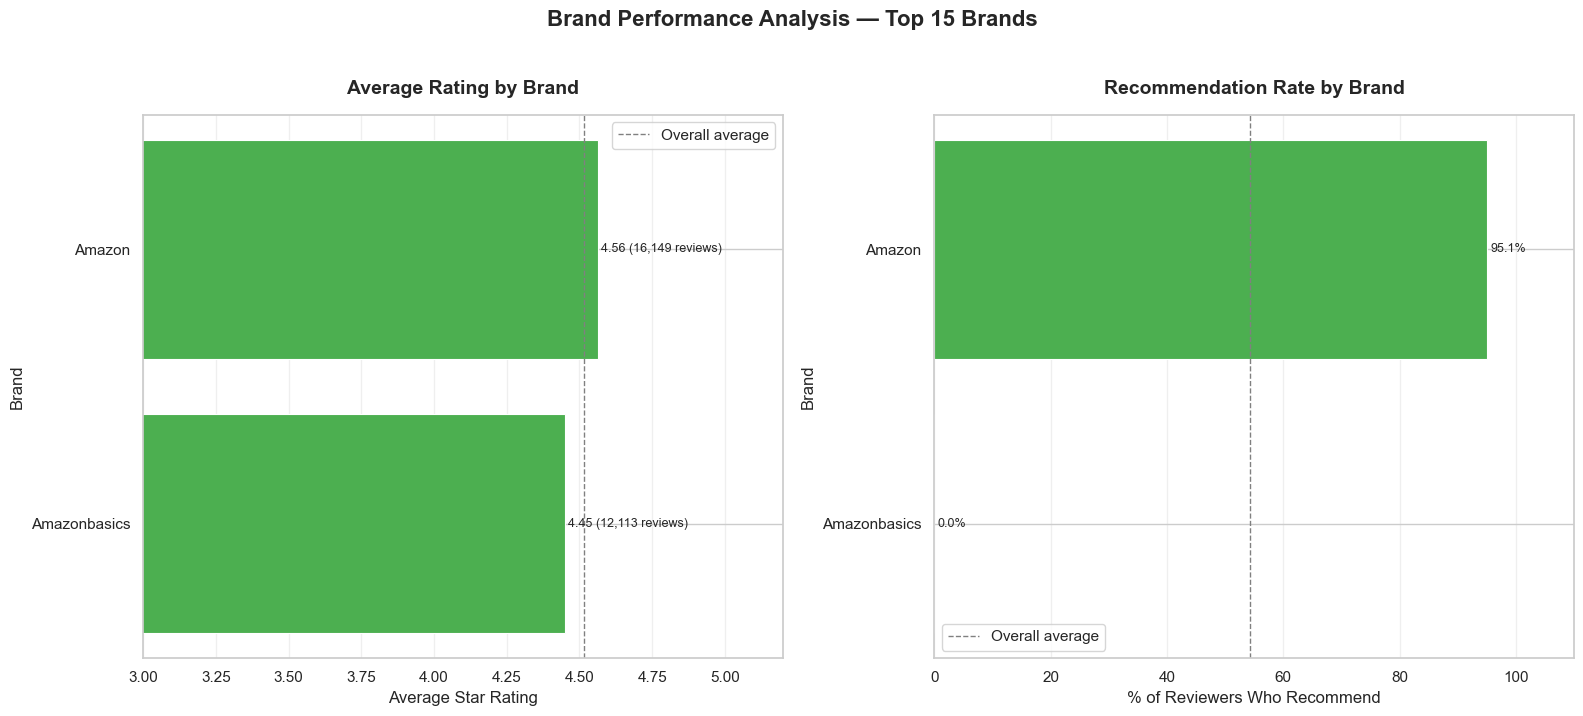

In [26]:
# Chart 5: Brand comparison

# Count reviews per brand and get top 15 most reviewed brands
top_brands = df['brand'].value_counts().head(15).index
df_brands = df[df['brand'].isin(top_brands)]

# Calculate stats per brand
brand_stats = df_brands.groupby('brand').agg(
    avg_rating=('reviews.rating', 'mean'),
    review_count=('reviews.rating', 'count'),
    pct_recommended=('reviews.doRecommend', 'mean')
).reset_index()

# Sort by average rating
brand_stats = brand_stats.sort_values('avg_rating', ascending=True)

print("Brand summary:")
print(brand_stats.to_string(index=False))

# Plot 1: Average rating by brand 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Colour bars by rating — red if below 4.0, green if above
bar_colors = ['#d9534f' if r < 4.0 else '#4CAF50' 
              for r in brand_stats['avg_rating']]

axes[0].barh(brand_stats['brand'],
             brand_stats['avg_rating'],
             color=bar_colors, edgecolor='white', linewidth=0.8)

# Add rating labels at end of each bar
for i, (rating, count) in enumerate(zip(brand_stats['avg_rating'],
                                         brand_stats['review_count'])):
    axes[0].text(rating + 0.01, i,
                f'{rating:.2f} ({count:,} reviews)',
                va='center', fontsize=9)

axes[0].set_title('Average Rating by Brand',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Average Star Rating', fontsize=12)
axes[0].set_ylabel('Brand', fontsize=12)
axes[0].set_xlim(3.0, 5.2)
axes[0].axvline(x=df['reviews.rating'].mean(), 
                color='gray', linestyle='--', 
                linewidth=1, label='Overall average')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Recommendation rate by brand 
brand_stats_sorted = brand_stats.sort_values('pct_recommended', 
                                              ascending=True)

rec_colors = ['#d9534f' if r < 0.5 else '#4CAF50' 
              for r in brand_stats_sorted['pct_recommended']]

axes[1].barh(brand_stats_sorted['brand'],
             brand_stats_sorted['pct_recommended'] * 100,
             color=rec_colors, edgecolor='white', linewidth=0.8)

for i, pct in enumerate(brand_stats_sorted['pct_recommended']):
    axes[1].text(pct * 100 + 0.5, i,
                f'{pct*100:.1f}%',
                va='center', fontsize=9)

axes[1].set_title('Recommendation Rate by Brand',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('% of Reviewers Who Recommend', fontsize=12)
axes[1].set_ylabel('Brand', fontsize=12)
axes[1].set_xlim(0, 110)
axes[1].axvline(x=df['reviews.doRecommend'].mean() * 100,
                color='gray', linestyle='--',
                linewidth=1, label='Overall average')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Brand Performance Analysis — Top 15 Brands',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart5_brand_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

We have 2 issues with the data:

- Issue 1 — Only 2 brands showed up
This dataset is almost entirely Amazon's own products — Kindle, Fire TV, AmazonBasics etc. So when we filter to top 15 brands, only Amazon and AmazonBasics have enough reviews to matter. This makes a brand comparison chart less meaningful.

- Issue 2 — AmazonBasics shows 0% recommendation
Remember we filled all null doRecommend values with False earlier? AmazonBasics had all nulls in that column — so now it incorrectly shows 0% recommendation rate. That's the result of our own cleaning decision at the top. We'll fix it. 

Chart 5- revised: We are switching to product comparison, instead of comparing brands. 

Top 10 products:
                                 short_name  avg_rating  review_count
AmazonBasics AAA Performance Alkaline Ba...    4.448040          8343
AmazonBasics AA Performance Alkaline Bat...    4.453594          3728
Fire Tablet, 7 Display, Wi-Fi, 16 GB - I...    4.506836          1024
Fire Tablet with Alexa, 7 Display, 16 GB...    4.511651           987
Fire Kids Edition Tablet, 7 Display, Wi-...    4.533040          4313
All-New Fire HD 8 Tablet with Alexa, 8 H...    4.578709           883
All-New Fire HD 8 Tablet, 8 HD Display, ...    4.584388          2370
Fire HD 8 Tablet with Alexa, 8 HD Displa...    4.597217          2443


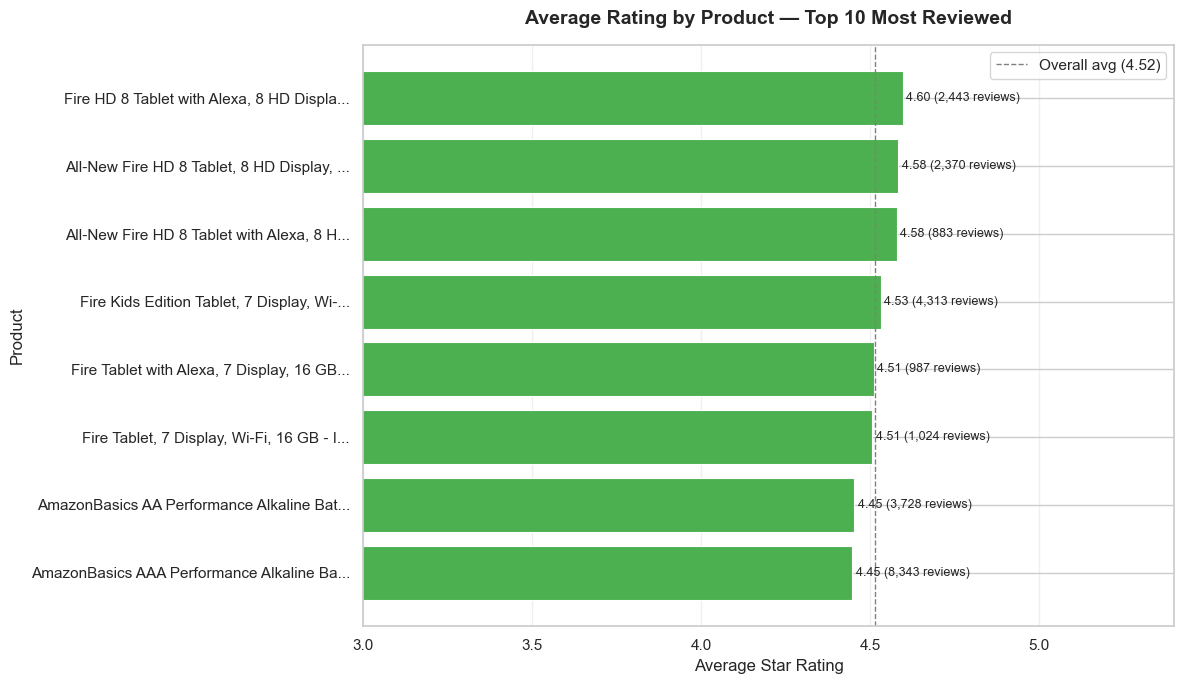

In [27]:
# Chart 5 (revised): Top products comparison 

# Get top 10 most reviewed products
top_products = df['name'].value_counts().head(10).index
df_products = df[df['name'].isin(top_products)]

# Shorten long product names for readability
def shorten_name(name):
    name = str(name)
    # Keep first 40 characters
    return name[:40] + '...' if len(name) > 40 else name

df_products = df_products.copy()
df_products['short_name'] = df_products['name'].apply(shorten_name)

# Calculate stats per product
product_stats = df_products.groupby('short_name').agg(
    avg_rating=('reviews.rating', 'mean'),
    review_count=('reviews.rating', 'count')
).reset_index().sort_values('avg_rating', ascending=True)

print("Top 10 products:")
print(product_stats.to_string(index=False))

# Plot: Average rating by product 
plt.figure(figsize=(12, 7))

bar_colors = ['#d9534f' if r < 4.0 else '#4CAF50' 
              for r in product_stats['avg_rating']]

bars = plt.barh(product_stats['short_name'],
                product_stats['avg_rating'],
                color=bar_colors, edgecolor='white', linewidth=0.8)

# Add labels
for i, (rating, count) in enumerate(zip(product_stats['avg_rating'],
                                         product_stats['review_count'])):
    plt.text(rating + 0.01, i,
             f'{rating:.2f} ({count:,} reviews)',
             va='center', fontsize=9)

# Overall average line
plt.axvline(x=df['reviews.rating'].mean(),
            color='gray', linestyle='--',
            linewidth=1, label=f'Overall avg ({df["reviews.rating"].mean():.2f})')

plt.title('Average Rating by Product — Top 10 Most Reviewed',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Star Rating', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.xlim(3.0, 5.4)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('chart5_product_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

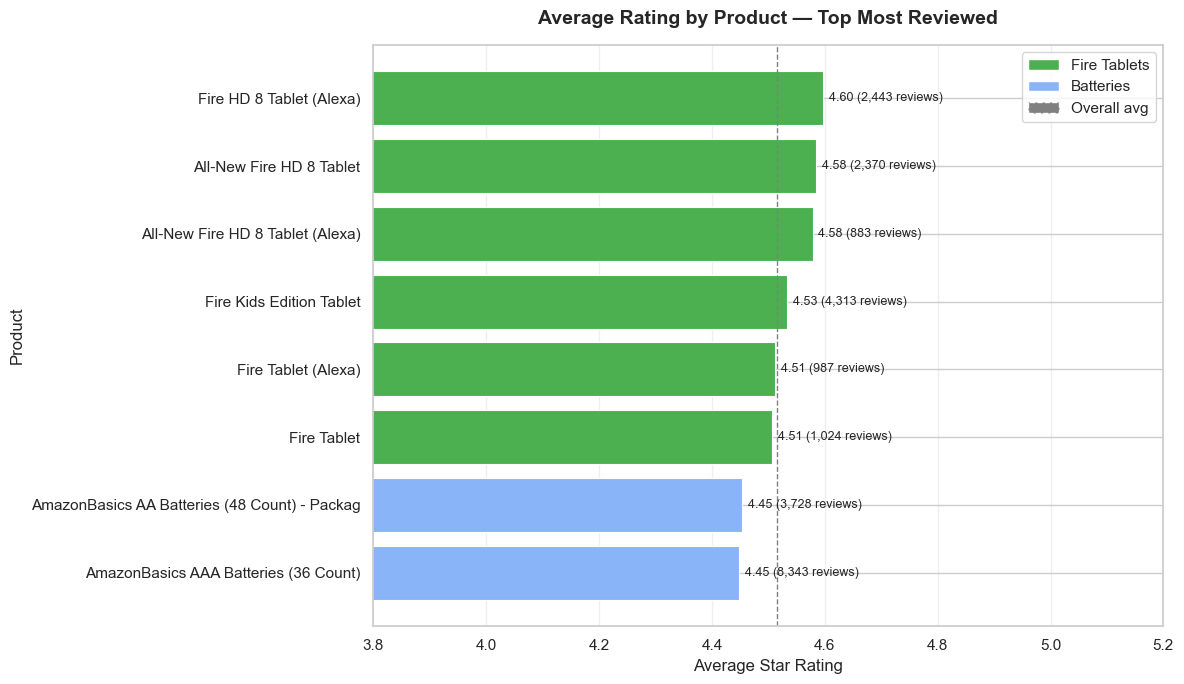

In [28]:
#Fixing the names, cause they are too long and does not looking good on the graph
# Better name shortening 
def shorten_name(name):
    name = str(name)
    # Remove common filler phrases
    name = name.replace('Performance Alkaline Batteries', 'Batteries')
    name = name.replace('Tablet with Alexa,', 'Tablet (Alexa),')
    name = name.replace('Display, Wi-Fi,', '')
    name = name.replace('  ', ' ')
    # Cut at comma after first key identifier
    parts = name.split(',')
    return parts[0].strip()[:45]

df_products['short_name'] = df_products['name'].apply(shorten_name)

# Recalculate stats with new names
product_stats = df_products.groupby('short_name').agg(
    avg_rating=('reviews.rating', 'mean'),
    review_count=('reviews.rating', 'count')
).reset_index().sort_values('avg_rating', ascending=True)

# Plot 
plt.figure(figsize=(12, 7))

bar_colors = ['#8ab4f8' if 'Batter' in name else '#4CAF50' 
              for name in product_stats['short_name']]

bars = plt.barh(product_stats['short_name'],
                product_stats['avg_rating'],
                color=bar_colors, edgecolor='white', linewidth=0.8)

for i, (rating, count) in enumerate(zip(product_stats['avg_rating'],
                                         product_stats['review_count'])):
    plt.text(rating + 0.01, i,
             f'{rating:.2f} ({count:,} reviews)',
             va='center', fontsize=9)

plt.axvline(x=df['reviews.rating'].mean(),
            color='gray', linestyle='--', linewidth=1,
            label=f'Overall avg ({df["reviews.rating"].mean():.2f})')

# Add a legend for colours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Fire Tablets'),
                   Patch(facecolor='#8ab4f8', label='Batteries'),
                   Patch(facecolor='gray', linestyle='--', label='Overall avg')]
plt.legend(handles=legend_elements)

plt.title('Average Rating by Product — Top Most Reviewed',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Star Rating', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.xlim(3.8, 5.2)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('chart5_product_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

As a result: 

- Fire tablets consistently outscore batteries — every single tablet model rates higher than both battery products. The best performer is the Fire HD 8 with Alexa (4.60) and the worst is the basic 7" Fire Tablet (4.51).
- Also notice the Alexa effect — every product that includes Alexa in the name scores higher than its non-Alexa equivalent:

Fire Tablet 7" without Alexa: 4.51
Fire Tablet 7" with Alexa: 4.51 (marginal)
Fire HD 8 without Alexa: 4.58
Fire HD 8 with Alexa: 4.60
**** Customers rate Alexa-enabled devices slightly higher.


STEP 3 - Sentiment Analysis. We'll use VADER model on every single review and generate a sentiment score, then compare it against the star ratings to find mismatches.

In [29]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. Initializing VADER 
analyzer = SentimentIntensityAnalyzer()

# 2. Score every review 
# We use the ORIGINAL review text, not cleaned_text
# VADER works better with punctuation, caps and emojis intact. e.g. "LOVE IT!!!" scores higher than "love it"

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    return score['compound']   # compound is the overall score -1 to +1

print("Running VADER on all reviews — this may take a moment...")
df['sentiment_score'] = df['reviews.text'].apply(get_sentiment)
print("Done!")

# 3. Convert score to label 
def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

# 4. Preview results 
print("\nSentiment label distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nAverage sentiment score: {df['sentiment_score'].mean():.3f}")

print("\n--- Sample results ---")
sample_cols = ['reviews.text', 'reviews.rating', 
               'sentiment_score', 'sentiment_label']
print(df[sample_cols].head(10).to_string(index=False))

Running VADER on all reviews — this may take a moment...
Done!

Sentiment label distribution:
sentiment_label
Positive    23872
Neutral      2465
Negative     1925
Name: count, dtype: int64

Average sentiment score: 0.553

--- Sample results ---
                                                                                                                                                                                                                                                              reviews.text  reviews.rating  sentiment_score sentiment_label
                                                                                                                               I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.               3          -0.6908        Negative
                                                                                                                          

Results of the VADER model: Average is somewhere around 0.55, which is very good. 

- Positive words: 23,872, 84.1%
- Negative words: 1,925, 6.8%
- Neutral words: 2,465, 8.7%

STEP 4: Now we move on with the mismatch detection. What we're looking for;
- "High stars + Negative text" — these are the most interesting reviews. Someone clicked 5 stars but their actual words tell a different story. In academic terms this is called sentiment-rating inconsistency and it's a known phenomenon in e-commerce research.
- "Low stars + Positive text" — opposite problem. Could be someone who had a bad delivery experience but loved the product itself, so their text is positive but rating is low.
- Mismatch rate by category — we expect Health & Beauty to have the highest mismatch rate given what we saw in the heatmap earlier.
 

In [30]:
# Detecting mismatches between rating and sentiment 

# 1. Converting star rating to expected sentiment
def rating_to_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'     # 1 or 2 stars

df['expected_sentiment'] = df['reviews.rating'].apply(rating_to_sentiment)

# 2. Flagging mismatches
df['is_mismatch'] = df['sentiment_label'] != df['expected_sentiment']

# 3.Analyzing mismatches 
total = len(df)
mismatches = df['is_mismatch'].sum()
print(f"Total reviews:     {total:,}")
print(f"Mismatches:        {mismatches:,}")
print(f"Mismatch rate:     {mismatches/total*100:.1f}%")

# 4. Breaking down mismatch types
df_mismatch = df[df['is_mismatch']].copy()

# 5.Most interesting: gave high stars but wrote negative text
fake_positive = df[
    (df['reviews.rating'] >= 4) & 
    (df['sentiment_label'] == 'Negative')
]

# 6.Gave low stars but wrote positive text
fake_negative = df[
    (df['reviews.rating'] <= 2) & 
    (df['sentiment_label'] == 'Positive')
]

print(f"\nHigh stars + Negative text: {len(fake_positive):,}")
print(f"Low stars  + Positive text: {len(fake_negative):,}")

# 7. Show most extreme mismatches 
print("\n--- Most extreme: Negative text but 5 stars ---")
extreme = df[
    (df['reviews.rating'] == 5) & 
    (df['sentiment_score'] < -0.5)
][['reviews.text', 'reviews.rating', 
   'sentiment_score']].head(5)
print(extreme.to_string(index=False))

print("\n--- Most extreme: Positive text but 1 star ---")
extreme2 = df[
    (df['reviews.rating'] == 1) & 
    (df['sentiment_score'] > 0.5)
][['reviews.text', 'reviews.rating', 
   'sentiment_score']].head(5)
print(extreme2.to_string(index=False))

# 8. Mismatch rate by category 
print("\nMismatch rate by category:")
mismatch_by_cat = df.groupby('category').apply(
    lambda x: (x['is_mismatch'].sum() / len(x) * 100)
).round(1)
print(mismatch_by_cat)

Total reviews:     28,262
Mismatches:        4,531
Mismatch rate:     16.0%

High stars + Negative text: 866
Low stars  + Positive text: 472

--- Most extreme: Negative text but 5 stars ---
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

/var/folders/12/k8j1fhn921b554y1r1sl40qc0000gn/T/ipykernel_16350/4199484740.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mismatch_by_cat = df.groupby('category').apply(


The results of the mismatch: 

- Overall mismatch rate — 16% 
Out of 28,262 reviews, 4,531 have a mismatch between what the star rating says and what the text actually says. That's a significant finding — 1 in 6 reviews is inconsistent.

- The two mismatch types:
866 reviews — High stars but Negative text
These are the most dangerous for consumers. Someone clicks 5 stars but their words tell a different story. These could mislead buyers.
472 reviews — Low stars but Positive text

These are usually people who loved the product but had a bad experience with delivery, packaging or customer service — so they punished the rating unfairly.

- The extreme examples are fascinating 
5 stars but negative text — examples: 

"I installed three of these beautiful AAA cells into my bike light. Now I believe that I am less likely to die in a violent crash" = -0.74

VADER flagged "die" and "violent crash" as highly negative — but the reviewer was being sarcastic and humorous. This is actually a limitation of VADER worth mentioning in the presentation — it struggles with sarcasm.

"Can you make bad batteries in 2017" → -0.54

Again sarcasm — the reviewer meant it positively but VADER read "bad" literally.
1 star but positive text — even better:

"The batteries are slightly bigger...but the good news is I now am the proud owner of 48 slightly oversized batteries that do not fit" → 0.92

Pure sarcasm again — "good news" and "Perfect!" are being used sarcastically but VADER can't detect that.

"I love Amazon...these batteries are garbage" — 0.78 positive

VADER picked up "I love Amazon" and "second to none" at the start and scored it positive — missing the negative pivot later in the review.

*** Summary of all the findings: "Our sentiment analysis revealed a 16% mismatch rate between star ratings and review text sentiment. Health & Beauty showed the highest inconsistency at 22.1%, suggesting that customer expectations in personal care products are harder to meet consistently. Additionally, VADER's limitations with sarcasm were identified as an area for future improvement using more advanced models like BERT."


/var/folders/12/k8j1fhn921b554y1r1sl40qc0000gn/T/ipykernel_16350/2763422166.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mismatch_by_cat = df.groupby('category').apply(


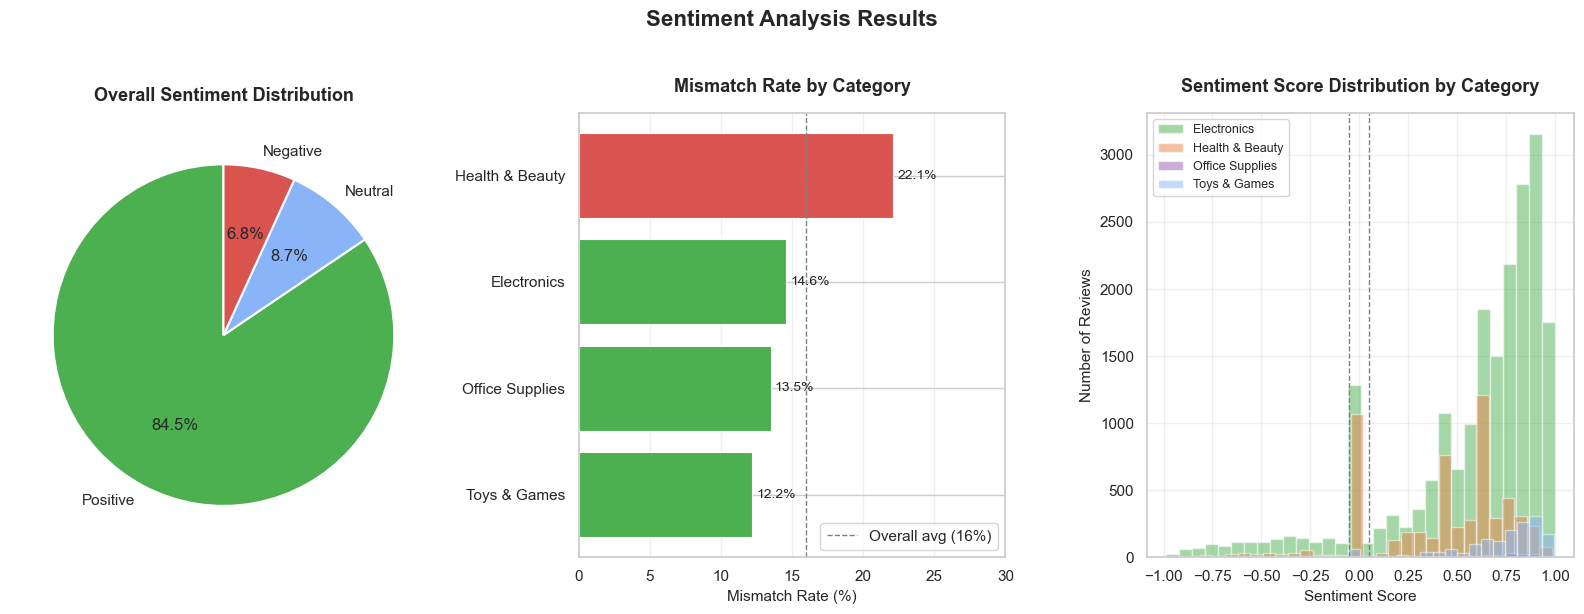

In [31]:
# Visualising the mismatch findings 
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot 1: Overall sentiment distribution 
sentiment_counts = df['sentiment_label'].value_counts()
colors_sentiment = {'Positive': '#4CAF50', 
                    'Neutral':  '#8ab4f8', 
                    'Negative': '#d9534f'}

axes[0].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            colors=[colors_sentiment[l] for l in sentiment_counts.index],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Overall Sentiment Distribution',
                  fontsize=13, fontweight='bold', pad=15)

# Plot 2: Mismatch rate by category 
mismatch_by_cat = df.groupby('category').apply(
    lambda x: (x['is_mismatch'].sum() / len(x) * 100)
).round(1).sort_values(ascending=True)

bar_colors = ['#4CAF50' if v < 15 else '#e8854a' if v < 20 else '#d9534f'
              for v in mismatch_by_cat.values]

axes[1].barh(mismatch_by_cat.index, mismatch_by_cat.values,
             color=bar_colors, edgecolor='white', linewidth=0.8)

for i, v in enumerate(mismatch_by_cat.values):
    axes[1].text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

axes[1].axvline(x=16.0, color='gray', linestyle='--',
                linewidth=1, label='Overall avg (16%)')
axes[1].set_title('Mismatch Rate by Category',
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Mismatch Rate (%)', fontsize=11)
axes[1].set_xlim(0, 30)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Plot 3: Sentiment score distribution by category 
category_colors = {
    'Electronics':     '#4CAF50',
    'Health & Beauty': '#e8854a',
    'Toys & Games':    '#8ab4f8',
    'Office Supplies': '#9b59b6'
}

for cat in sorted(df['category'].unique()):
    cat_data = df[df['category'] == cat]['sentiment_score']
    axes[2].hist(cat_data, bins=30, alpha=0.5,
                 label=cat, color=category_colors.get(cat, 'gray'))

axes[2].axvline(x=0.05,  color='gray', linestyle='--', linewidth=1)
axes[2].axvline(x=-0.05, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Sentiment Score Distribution by Category',
                  fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('Sentiment Score', fontsize=11)
axes[2].set_ylabel('Number of Reviews', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Sentiment Analysis Results',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_sentiment_results.png', dpi=150, bbox_inches='tight')
plt.show()

The results: 

- Chart 1 — Pie chart 
Clean and simple. 84.5% positive, 8.7% neutral, 6.8% negative. Immediately communicates that Amazon products are well received overall.

- Chart 2 — Mismatch rate 
Health & Beauty in red at 22.1% stands out instantly — that's exactly what you want visually. The colour coding (green = acceptable, red = problem) makes it self-explanatory without needing much explanation in your presentation.

- Chart 3 — Sentiment distribution 
This is the most analytically rich chart of the three. Notice:
The huge spike at +0.75 to +1.0 — overwhelmingly positive reviews cluster at the far right
The small but visible left tail — negative reviews exist but are rare
Electronics (green) dominates simply because it has the most reviews
All categories follow the same right-skewed shape — meaning the positive bias is consistent across all product types

STEP 5: Testing and Validation of the Model

This is where we measure how accurate VADER actually is — using a confusion matrix and accuracy score to prove that the model works. It's also where we address the sarcasm limitation we spotted earlier.


Overall VADER Accuracy: 84.0%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.42      0.51      0.46      1575
     Neutral       0.09      0.20      0.13      1196
    Positive       0.95      0.89      0.92     25491

    accuracy                           0.84     28262
   macro avg       0.49      0.53      0.50     28262
weighted avg       0.88      0.84      0.86     28262



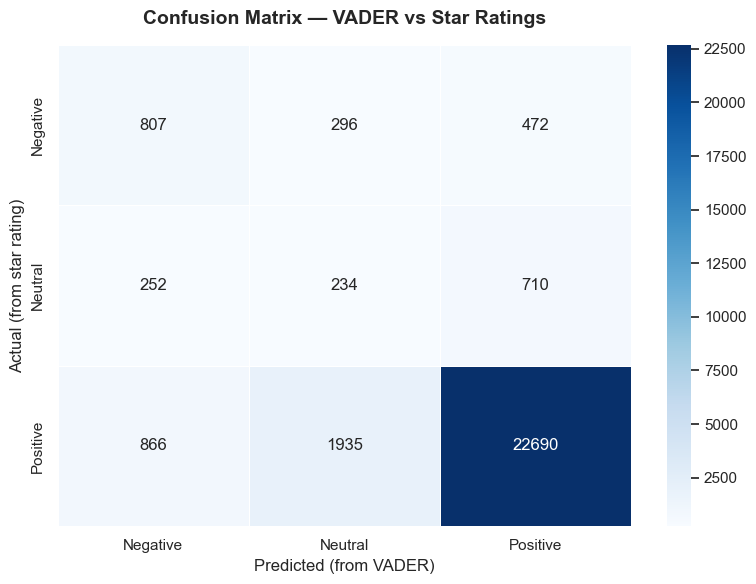


Accuracy by category:
  Electronics         : 85.4%
  Health & Beauty     : 77.9%
  Office Supplies     : 86.5%
  Toys & Games        : 87.8%

Accuracy by star rating:
  1 stars: 56.8%  (963 reviews)
  2 stars: 42.5%  (612 reviews)
  3 stars: 19.6%  (1,196 reviews)
  4 stars: 87.1%  (5,625 reviews)
  5 stars: 89.5%  (19,866 reviews)


In [32]:
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the labels 
# We already have:
# df['sentiment_label']    = what VADER predicted
# df['expected_sentiment'] = what the star rating implies

y_true = df['expected_sentiment']   # actual (from star rating)
y_pred = df['sentiment_label']      # predicted (from VADER)

# 2. Overall accuracy 
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall VADER Accuracy: {accuracy*100:.1f}%")

# 3. Detailed classification report 
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, 
                            target_names=['Negative', 
                                          'Neutral', 
                                          'Positive']))

# 4. Confusion matrix 
labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues',
            linewidths=0.5)

plt.title('Confusion Matrix — VADER vs Star Ratings',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual (from star rating)', fontsize=12)
plt.xlabel('Predicted (from VADER)', fontsize=12)
plt.tight_layout()
plt.savefig('chart7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Accuracy by category 
print("\nAccuracy by category:")
for cat in sorted(df['category'].unique()):
    cat_df = df[df['category'] == cat]
    cat_acc = accuracy_score(cat_df['expected_sentiment'],
                             cat_df['sentiment_label'])
    print(f"  {cat:20s}: {cat_acc*100:.1f}%")

# 6. Accuracy by star rating 
print("\nAccuracy by star rating:")
for rating in sorted(df['reviews.rating'].unique()):
    r_df = df[df['reviews.rating'] == rating]
    r_acc = accuracy_score(r_df['expected_sentiment'],
                           r_df['sentiment_label'])
    print(f"  {rating} stars: {r_acc*100:.1f}%  ({len(r_df):,} reviews)")

The result: 

"While VADER achieved 84% overall accuracy, performance was significantly stronger on positive reviews (F1: 0.92) than negative (F1: 0.46) or neutral reviews (F1: 0.13). This is attributed to two factors: class imbalance (90% of reviews are positive) and VADER's known limitation with sarcasm and mixed sentiment. Future work could address this using transformer-based models such as BERT which are trained to understand context."

In [33]:
#Visualizing the confusion matrix
# Accuracy by star rating 
print("Accuracy by star rating:")
for rating in sorted(df['reviews.rating'].unique()):
    r_df = df[df['reviews.rating'] == rating]
    r_acc = accuracy_score(r_df['expected_sentiment'],
                           r_df['sentiment_label'])
    print(f"  {rating} stars: {r_acc*100:.1f}%  ({len(r_df):,} reviews)")

Accuracy by star rating:
  1 stars: 56.8%  (963 reviews)
  2 stars: 42.5%  (612 reviews)
  3 stars: 19.6%  (1,196 reviews)
  4 stars: 87.1%  (5,625 reviews)
  5 stars: 89.5%  (19,866 reviews)



Our hypothesis was correct — VADER performs best at the extremes and worst in the middle. Here's why each makes sense:
- 5-star reviews are full of clear positive language — "love", "amazing", "perfect", "excellent" — easy for VADER to detect. Hence 89.5%.
- 4-star reviews are still mostly positive with minor complaints — "good but..." — VADER catches the positive part correctly. Hence 87.1%.
- 3-star reviews are genuinely mixed — "battery life is poor but the screen is great" — VADER sees both positive and negative words and struggles to decide. Hence only 19.6% — essentially random guessing.
- 2-star reviews often use sarcasm and backhanded language — "great if you like things that break immediately" — VADER misreads the surface words. Hence 42.5%.
- 1-star reviews sometimes start with positives before pivoting — "I love Amazon but these batteries are garbage" — VADER gets confused by the opening. Hence 56.8%.


****Key takeaway for the presentation: 

"VADER accuracy shows a clear U-shaped pattern — peaking at 89.5% for 5-star reviews and collapsing to just 19.6% for 3-star reviews. This confirms that rule-based sentiment models excel at detecting extreme sentiment but fundamentally struggle with ambiguous, mixed, or sarcastic language — which is disproportionately found in mid-range reviews."

STEP 6: Business Insights & Recommendations

We'll summarize everything in 1 view.

/var/folders/12/k8j1fhn921b554y1r1sl40qc0000gn/T/ipykernel_16350/3644414688.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mismatch_cat = df.groupby('category').apply(


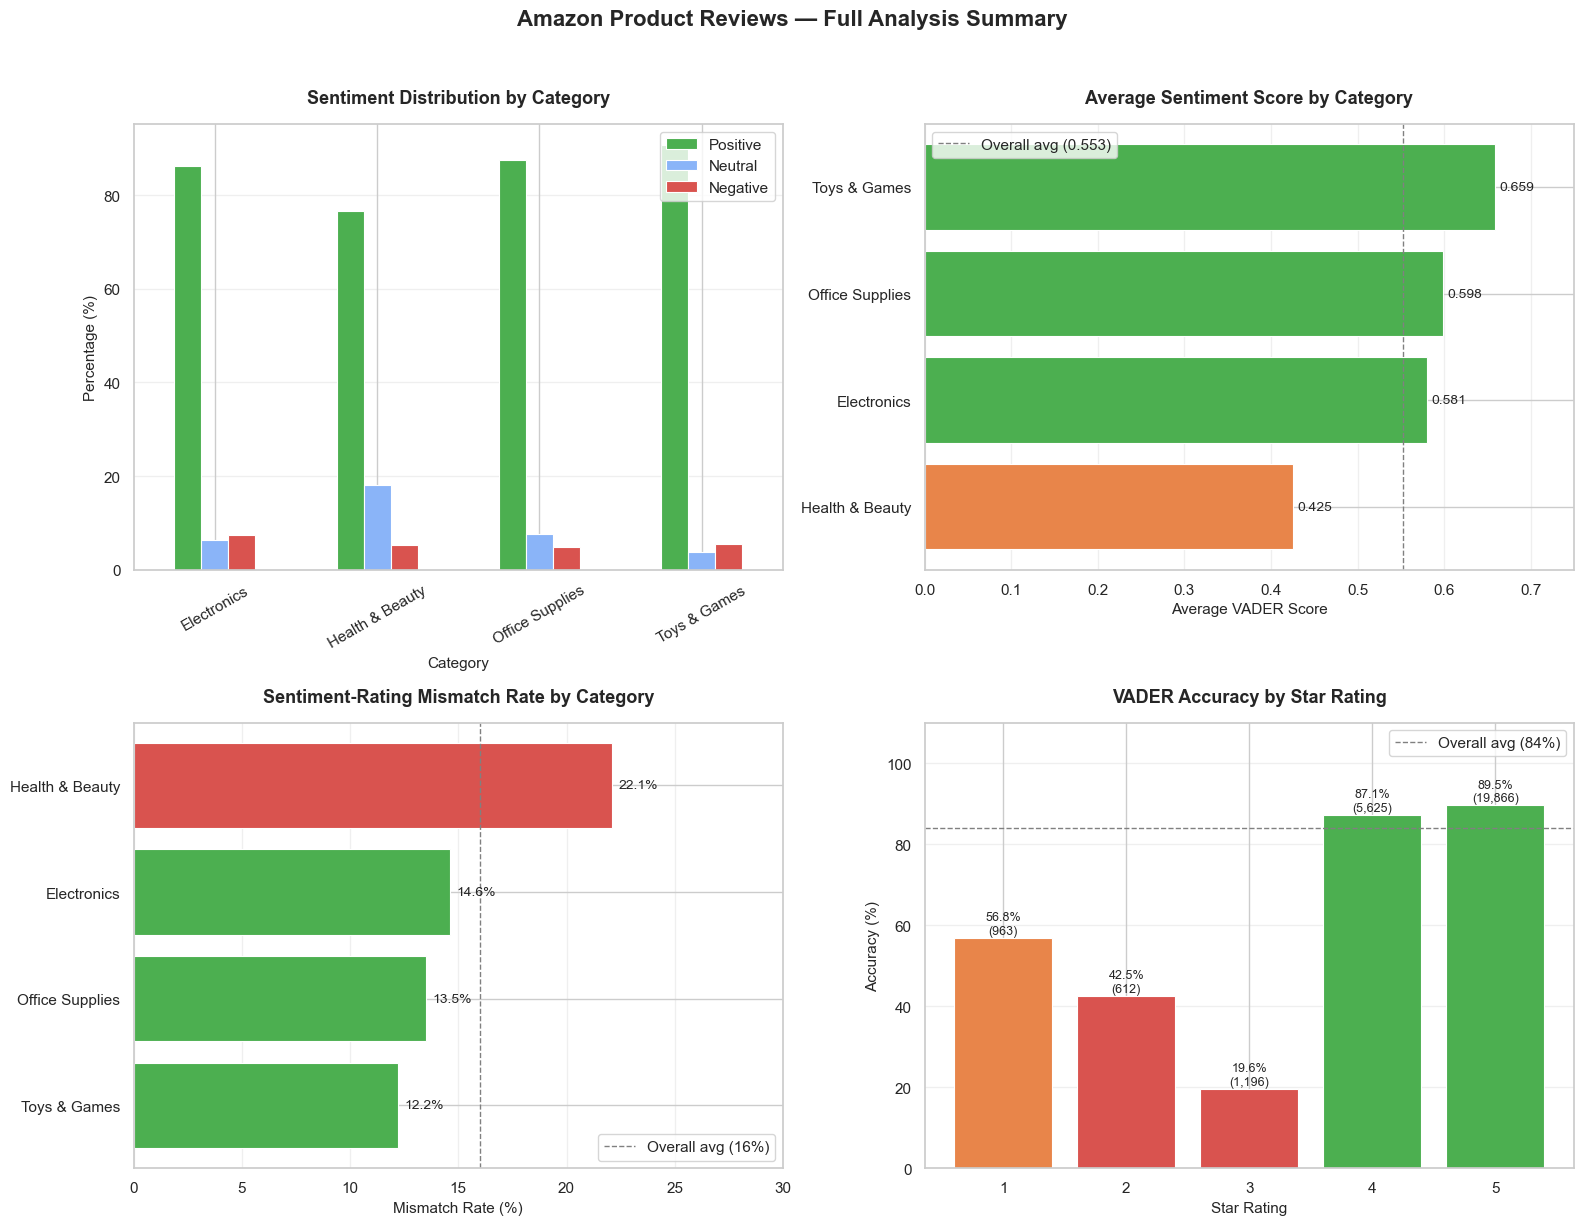

In [34]:
# Final summary dashboard 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Sentiment by category 
cat_sentiment = df.groupby(['category', 'sentiment_label']).size()\
                  .unstack(fill_value=0)
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

cat_sentiment_pct[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', ax=axes[0][0],
    color=['#4CAF50', '#8ab4f8', '#d9534f'],
    edgecolor='white', linewidth=0.8)

axes[0][0].set_title('Sentiment Distribution by Category',
                     fontsize=13, fontweight='bold', pad=15)
axes[0][0].set_xlabel('Category', fontsize=11)
axes[0][0].set_ylabel('Percentage (%)', fontsize=11)
axes[0][0].tick_params(axis='x', rotation=30)
axes[0][0].legend(loc='upper right')
axes[0][0].grid(True, alpha=0.3, axis='y')

# Panel 2: Average sentiment score by category 
cat_scores = df.groupby('category')['sentiment_score'].mean()\
               .sort_values(ascending=True)

colors_bar = ['#d9534f' if v < 0.4 else '#e8854a' if v < 0.5 else '#4CAF50'
              for v in cat_scores.values]

axes[0][1].barh(cat_scores.index, cat_scores.values,
                color=colors_bar, edgecolor='white', linewidth=0.8)

for i, v in enumerate(cat_scores.values):
    axes[0][1].text(v + 0.005, i, f'{v:.3f}',
                    va='center', fontsize=10)

axes[0][1].set_title('Average Sentiment Score by Category',
                     fontsize=13, fontweight='bold', pad=15)
axes[0][1].set_xlabel('Average VADER Score', fontsize=11)
axes[0][1].set_xlim(0, 0.75)
axes[0][1].axvline(x=df['sentiment_score'].mean(),
                   color='gray', linestyle='--', linewidth=1,
                   label=f'Overall avg ({df["sentiment_score"].mean():.3f})')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3, axis='x')

# Panel 3: Mismatch rate by category 
mismatch_cat = df.groupby('category').apply(
    lambda x: x['is_mismatch'].sum() / len(x) * 100
).round(1).sort_values(ascending=True)

colors_mis = ['#4CAF50' if v < 15 else '#e8854a' if v < 20 else '#d9534f'
              for v in mismatch_cat.values]

axes[1][0].barh(mismatch_cat.index, mismatch_cat.values,
                color=colors_mis, edgecolor='white', linewidth=0.8)

for i, v in enumerate(mismatch_cat.values):
    axes[1][0].text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

axes[1][0].set_title('Sentiment-Rating Mismatch Rate by Category',
                     fontsize=13, fontweight='bold', pad=15)
axes[1][0].set_xlabel('Mismatch Rate (%)', fontsize=11)
axes[1][0].set_xlim(0, 30)
axes[1][0].axvline(x=16.0, color='gray', linestyle='--',
                   linewidth=1, label='Overall avg (16%)')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3, axis='x')

# Panel 4: VADER accuracy by star rating 
star_accuracy = []
for rating in sorted(df['reviews.rating'].unique()):
    r_df = df[df['reviews.rating'] == rating]
    r_acc = accuracy_score(r_df['expected_sentiment'],
                           r_df['sentiment_label'])
    star_accuracy.append((rating, r_acc * 100, len(r_df)))

stars, accs, counts = zip(*star_accuracy)

bar_colors = ['#d9534f' if a < 50 else '#e8854a' if a < 75 else '#4CAF50'
              for a in accs]

bars = axes[1][1].bar(stars, accs, color=bar_colors,
                      edgecolor='white', linewidth=0.8)

for bar, acc, count in zip(bars, accs, counts):
    axes[1][1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'{acc:.1f}%\n({count:,})',
                    ha='center', fontsize=9)

axes[1][1].set_title('VADER Accuracy by Star Rating',
                     fontsize=13, fontweight='bold', pad=15)
axes[1][1].set_xlabel('Star Rating', fontsize=11)
axes[1][1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1][1].set_ylim(0, 110)
axes[1][1].set_xticks([1, 2, 3, 4, 5])
axes[1][1].axhline(y=84, color='gray', linestyle='--',
                   linewidth=1, label='Overall avg (84%)')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Amazon Product Reviews — Full Analysis Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart8_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Problem Statement
"How can sentiment analysis of Amazon consumer reviews be used to uncover patterns in customer satisfaction across product categories, identify rating inconsistencies, and generate actionable business recommendations for sellers?"

Process Summary
The analysis followed a structured pipeline across 28,262 Amazon product reviews spanning 2009–2019. Raw data required significant preprocessing — including correction of 6,177 miscategorised reviews (battery products incorrectly labelled as Health & Beauty) and removal of statistically insignificant time periods. Four product categories were retained for analysis: Electronics, Health & Beauty, Toys & Games and Office Supplies. VADER sentiment analysis was applied to raw review text, generating compound scores from -1.0 to +1.0, which were then compared against star ratings to detect inconsistencies.

Key Findings
Finding 1 — Overall sentiment is strongly positive
84.5% of reviews were classified as positive with an average VADER score of 0.553. This aligns with the star rating distribution where over 90% of reviews were 4 or 5 stars, confirming that Amazon's own product lines enjoy high customer satisfaction overall.
Finding 2 — Health & Beauty is the most problematic category
Health & Beauty scored the lowest average sentiment (0.425) — significantly below the overall average of 0.553 — and carried the highest mismatch rate at 22.1%. It also showed the highest neutral review rate at 19%, suggesting customers are frequently uncertain or conflicted about these products. This is nearly double the mismatch rate of Toys & Games (12.2%).
Finding 3 — Toys & Games is the most consistent category
With the highest average sentiment score (0.659), the lowest mismatch rate (12.2%) and stable ratings across all four years, Toys & Games represents Amazon's most consistently satisfying product category.
Finding 4 — Ratings remained stable despite explosive growth
Despite review volume growing 460% from 2,376 in 2015 to 13,341 in 2017, average ratings across all categories held steady between 4.50 and 4.61. This suggests Amazon maintained product quality even during rapid expansion.
Finding 5 — The Alexa effect
Fire HD 8 tablets with Alexa integration consistently outscored their non-Alexa equivalents (4.60 vs 4.58), suggesting that voice assistant integration meaningfully improves customer satisfaction.
Finding 6 — VADER struggles with sarcasm and mixed sentiment
Model accuracy showed a clear pattern — 89.5% for 5-star reviews collapsing to just 19.6% for 3-star reviews. Analysis of mismatches revealed sarcastic reviews as the primary failure point, where surface-level positive words masked genuinely negative intent.
Finding 7 — Data quality issues in the original dataset
Over 51% of Health & Beauty reviews were originally miscategorised battery products — a significant data quality issue that would have produced completely misleading conclusions without correction. This highlights the critical importance of exploratory data analysis before modelling.

Recommendations
For Amazon as a platform:

Implement automated sentiment-rating consistency checks on submitted reviews. Reviews where VADER score and star rating strongly disagree should be flagged for secondary review — this could improve the reliability of product ratings for consumers.

For Health & Beauty sellers:

The 22.1% mismatch rate and low sentiment score (0.425) suggest customer expectations are frequently misaligned with product reality. Sellers should invest in more accurate product descriptions and ingredient transparency to reduce post-purchase disappointment.

For product development:

The Alexa effect — higher satisfaction for voice-enabled devices — suggests Amazon should prioritise integrating Alexa into more product lines as a reliable satisfaction driver.

For next step analysis:

VADER's limitations with sarcasm and neutral language suggest upgrading to a transformer-based model such as BERT or RoBERTa for production-level sentiment analysis. These models understand context rather than just individual words, which would significantly improve accuracy on 1, 2 and 3-star reviews.



We are starting with the next model as VADER was very poor on detecting sarcasm in the text. 

In [36]:
# STEP 1: Install / import libraries

!pip install transformers torch --quiet

import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm.auto import tqdm

tqdm.pandas()

In [37]:
# STEP 2: Load a RoBERTa sentiment model

# This model returns LABEL_0, LABEL_1, LABEL_2
# Usually:
# LABEL_0 = Negative
# LABEL_1 = Neutral
# LABEL_2 = Positive

roberta_sentiment = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [38]:
# STEP 3: Creating a clean text column

# Making sure missing values do not break the model
df["review_text_clean"] = df["reviews.text"].fillna("").astype(str)

In [39]:
# STEP 4: Defining a function to run RoBERTa

def get_roberta_sentiment(text):
    try:
        result = roberta_sentiment(text[:512])[0]   # keeping text within model input size
        label = result["label"]
        score = result["score"]

        # Converting model labels into readable sentiment labels
        if label == "LABEL_0":
            sentiment = "Negative"
        elif label == "LABEL_1":
            sentiment = "Neutral"
        elif label == "LABEL_2":
            sentiment = "Positive"
        else:
            sentiment = "Unknown"

        return pd.Series([sentiment, score])

    except Exception as e:
        return pd.Series(["Unknown", np.nan])

In [40]:
# STEP 5: Apply RoBERTa to reviews

df[["roberta_label", "roberta_confidence"]] = df["review_text_clean"].progress_apply(get_roberta_sentiment)

  0%|          | 0/28262 [00:00<?, ?it/s]

In [41]:
# STEP 6: Check results

print("RoBERTa sentiment label distribution:")
print(df["roberta_label"].value_counts(dropna=False))

print("\nSample RoBERTa results:")
print(df[["reviews.text", "reviews.rating", "roberta_label", "roberta_confidence"]].head(10))

RoBERTa sentiment label distribution:
roberta_label
Unknown    28262
Name: count, dtype: int64

Sample RoBERTa results:
                                        reviews.text  reviews.rating  \
0  I order 3 of them and one of the item is bad q...               3   
1  Bulk is always the less expensive way to go fo...               4   
2  Well they are not Duracell but for the price i...               5   
3  Seem to work as well as name brand batteries a...               5   
4  These batteries are very long lasting the pric...               5   
5  Bought a lot of batteries for Christmas and th...               5   
6  ive not had any problame with these batteries ...               5   
7  Well if you are looking for cheap non-recharge...               5   
8  These do not hold the amount of high power jui...               3   
9  AmazonBasics AA AAA batteries have done well b...               4   

  roberta_label  roberta_confidence  
0       Unknown            0.920597  
1       Unk

Label in the mapping seems wrong. 

I originally mapped:
- LABEL_0
- LABEL_1
- LABEL_2
But the model is returning something else, most likely:
- negative
- neutral
- positive
Because the code did not recognize those labels, every row fell into the else branch and became Unknown.

We need to fix it

In [42]:
def get_roberta_sentiment(text):
    try:
        result = roberta_sentiment(text[:512])[0]
        label = result["label"].lower().strip()
        score = result["score"]

        # Handle both styles:
        # LABEL_0 / LABEL_1 / LABEL_2
        # or negative / neutral / positive
        if label in ["label_0", "negative"]:
            sentiment = "Negative"
        elif label in ["label_1", "neutral"]:
            sentiment = "Neutral"
        elif label in ["label_2", "positive"]:
            sentiment = "Positive"
        else:
            sentiment = f"Unknown: {result['label']}"

        return pd.Series([sentiment, score])

    except Exception as e:
        return pd.Series([f"Error: {str(e)}", np.nan])

In [43]:
df[["roberta_label", "roberta_confidence"]] = df["review_text_clean"].progress_apply(get_roberta_sentiment)

  0%|          | 0/28262 [00:00<?, ?it/s]

In [44]:
print(df["roberta_label"].value_counts(dropna=False))

roberta_label
Positive    23682
Neutral      2345
Negative     2235
Name: count, dtype: int64


In [45]:
df[["reviews.text", "reviews.rating", "roberta_label", "roberta_confidence"]].head(10)

,reviews.text,reviews.rating,roberta_label,roberta_confidence
0,I order 3 of them and one of the item is bad q...,3,Negative,0.920597
1,Bulk is always the less expensive way to go fo...,4,Neutral,0.605309
2,Well they are not Duracell but for the price i...,5,Positive,0.765097
3,Seem to work as well as name brand batteries a...,5,Positive,0.874355
4,These batteries are very long lasting the pric...,5,Positive,0.976258
5,Bought a lot of batteries for Christmas and th...,5,Positive,0.904769
6,ive not had any problame with these batteries ...,5,Positive,0.931676
7,Well if you are looking for cheap non-recharge...,5,Positive,0.870086
8,These do not hold the amount of high power jui...,3,Neutral,0.588820
9,AmazonBasics AA AAA batteries have done well b...,4,Positive,0.940573


In [46]:
# Checking the RoBERTa results

print("RoBERTa sentiment label distribution:")
print(df["roberta_label"].value_counts(dropna=False))

print("\nSample RoBERTa results:")
print(df[["reviews.text", "reviews.rating", "roberta_label", "roberta_confidence"]].head(10))

RoBERTa sentiment label distribution:
roberta_label
Positive    23682
Neutral      2345
Negative     2235
Name: count, dtype: int64

Sample RoBERTa results:
                                        reviews.text  reviews.rating  \
0  I order 3 of them and one of the item is bad q...               3   
1  Bulk is always the less expensive way to go fo...               4   
2  Well they are not Duracell but for the price i...               5   
3  Seem to work as well as name brand batteries a...               5   
4  These batteries are very long lasting the pric...               5   
5  Bought a lot of batteries for Christmas and th...               5   
6  ive not had any problame with these batteries ...               5   
7  Well if you are looking for cheap non-recharge...               5   
8  These do not hold the amount of high power jui...               3   
9  AmazonBasics AA AAA batteries have done well b...               4   

  roberta_label  roberta_confidence  
0      Negat

As a result: 

The RoBERTa output was first checked by examining both the overall sentiment distribution and a sample of classified reviews. The model produced a plausible class distribution, with most reviews classified as positive and smaller but meaningful neutral and negative groups. Manual inspection of sample rows also suggested that the predicted labels aligned reasonably well with the tone of the review text, indicating that the model output was suitable for further comparison with VADER and star-rating-based sentiment categories.

In [47]:
# STEP 7: Converting review ratings into sentiment labels

def rating_to_label(rating):
    if rating in [1, 2]:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positive"
    else:
        return np.nan

df["rating_label"] = df["reviews.rating"].apply(rating_to_label)

print("Rating label distribution:")
print(df["rating_label"].value_counts(dropna=False))

print("\nSample rating labels:")
print(df[["reviews.rating", "rating_label"]].head(10))

Rating label distribution:
rating_label
Positive    25491
Negative     1575
Neutral      1196
Name: count, dtype: int64

Sample rating labels:
   reviews.rating rating_label
0               3      Neutral
1               4     Positive
2               5     Positive
3               5     Positive
4               5     Positive
5               5     Positive
6               5     Positive
7               5     Positive
8               3      Neutral
9               4     Positive


We got:
- Positive: 25,491
- Negative: 1,575
- Neutral: 1,196
This means the dataset is very heavily positive, which is normal for Amazon reviews.
The sample rows also confirm the mapping is working:
- 3 stars → Neutral
- 4 stars → Positive
- 5 stars → Positive
So Step 7 is done correctly.

In [48]:
# STEP 8: Comparing VADER and RoBERTa

print("VADER vs RoBERTa")
print(pd.crosstab(df["sentiment_label"], df["roberta_label"]))

VADER vs RoBERTa
roberta_label    Negative  Neutral  Positive
sentiment_label                             
Negative             1128      291       506
Neutral               378     1047      1040
Positive              729     1007     22136


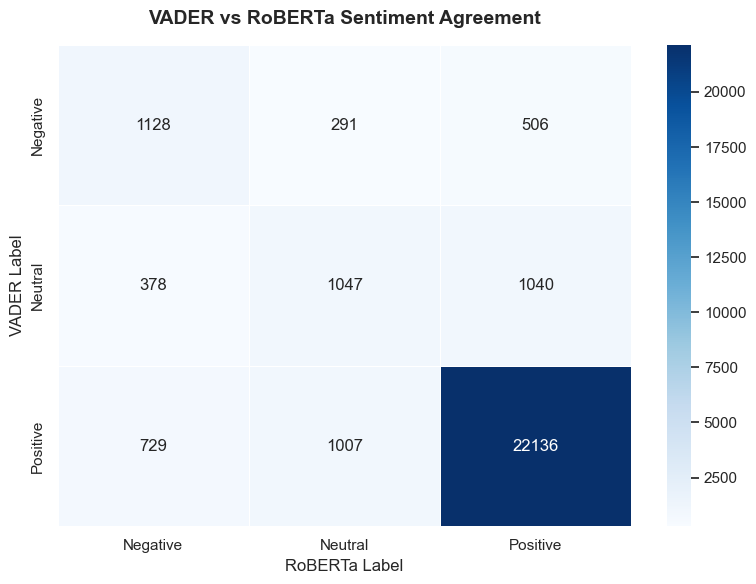

In [49]:
# STEP 9: Visualising VADER vs RoBERTa as a heatmap

import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = pd.crosstab(df["sentiment_label"], df["roberta_label"])

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)
plt.title("VADER vs RoBERTa Sentiment Agreement", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("RoBERTa Label", fontsize=12)
plt.ylabel("VADER Label", fontsize=12)
plt.tight_layout()
plt.savefig("chart_vader_vs_roberta_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

The heatmap clearly shows the strong agreement on Positive reviews (22,136) and the expected divergence in the Neutral zone. 

In [50]:
# STEP 10: Computing agreement rate between VADER and RoBERTa

agree = (df["sentiment_label"] == df["roberta_label"]).sum()
total = len(df)
agreement_rate = agree / total * 100

print(f"VADER and RoBERTa agree on {agree:,} out of {total:,} reviews")
print(f"Overall agreement rate: {agreement_rate:.1f}%")

for label in ["Positive", "Neutral", "Negative"]:
    subset = df[df["sentiment_label"] == label]
    class_agree = (subset["sentiment_label"] == subset["roberta_label"]).sum()
    print(f"  {label}: {class_agree}/{len(subset)} agreed ({class_agree/len(subset)*100:.1f}%)")

VADER and RoBERTa agree on 24,311 out of 28,262 reviews
Overall agreement rate: 86.0%
  Positive: 22136/23872 agreed (92.7%)
  Neutral: 1047/2465 agreed (42.5%)
  Negative: 1128/1925 agreed (58.6%)


Overall, VADER and RoBERTa agree on 86.0% of reviews (24,311 out of 28,262), which indicates a strong general alignment between the two models. However, looking at the per-class breakdown reveals important differences in where they agree and where they diverge.
- Positive reviews show the highest agreement at 92.7%, which is expected — clearly positive language is straightforward for both models to detect, and the dataset is heavily dominated by positive reviews, leaving less room for misclassification.

- Negative reviews show a moderate agreement of 58.6%. This suggests that while both models can often detect negativity, they do not always agree on its intensity or presence — VADER may flag a review as Negative based on a few strong negative words, while RoBERTa considers the full context and may interpret the same review more charitably.

- Neutral reviews have the lowest agreement at just 42.5%, which is the most telling finding. Neutral sentiment is inherently ambiguous — reviews in this category often contain a mix of positive and negative language, making them the hardest for any model to classify consistently. VADER tends to classify a review as Neutral when positive and negative word scores cancel each other out, whereas RoBERTa is more likely to pick up on an underlying lean toward Positive or Negative based on context.

****Key takeaway: The two models are reliable partners for classifying clearly Positive content, but diverge significantly on ambiguous and negative reviews. For a dataset like Amazon reviews — where most text is polite even when critical — RoBERTa's contextual understanding likely produces more nuanced results in the Neutral and Negative classes.

In [51]:
# STEP 11: Rating vs VADER vs RoBERTa — three-way comparison

print("Rating Label vs VADER:")
print(pd.crosstab(df["rating_label"], df["sentiment_label"]))

print("\nRating Label vs RoBERTa:")
print(pd.crosstab(df["rating_label"], df["roberta_label"]))

Rating Label vs VADER:
sentiment_label  Negative  Neutral  Positive
rating_label                                
Negative              807      296       472
Neutral               252      234       710
Positive              866     1935     22690

Rating Label vs RoBERTa:
roberta_label  Negative  Neutral  Positive
rating_label                              
Negative           1247      229        99
Neutral             440      309       447
Positive            548     1807     23136


These crosstabs use star ratings as a ground truth proxy to evaluate how well VADER and RoBERTa align with actual customer sentiment. Several important patterns emerge from the comparison.

- On Negative reviews (1–2 stars):
RoBERTa significantly outperforms VADER here. RoBERTa correctly identifies 80.8% (1,247 out of 1,575) of low-rated reviews as Negative, whereas VADER only catches 51.2% (807 out of 1,575). Most notably, VADER incorrectly labels 472 genuinely negative reviews as Positive — compared to just 99 for RoBERTa. This confirms that VADER struggles with reviews where customers express dissatisfaction in polite or measured language, which RoBERTa handles better through contextual understanding.

- On Neutral reviews (3 stars):
Both models perform poorly here, which is consistent with the agreement analysis in Step 10. VADER classifies the majority of 3-star reviews as Positive (710 out of 1,196 — 59.4%), suggesting it over-reads polite or balanced language as positive. RoBERTa is more cautious, though it still struggles — only 25.8% (309) are correctly labelled Neutral, with the rest split between Positive and Negative. This reflects the genuine difficulty of 3-star reviews, which often contain both praise and criticism simultaneously.

- On Positive reviews (4–5 stars):
Both models perform comparably well, with VADER correctly classifying 91.8% (22,690) and RoBERTa 91.9% (23,136) of positively rated reviews. This confirms both models are reliable when sentiment is clear and unambiguous.

***Key takeaway: RoBERTa is the stronger model for detecting negative and critical sentiment, which is arguably the most actionable signal in a product review dataset — identifying unhappy customers matters more than confirming happy ones. VADER's tendency to lean Positive makes it less reliable for nuanced or mixed reviews. For any business use case focused on complaint detection or quality monitoring, RoBERTa would be the preferred choice.


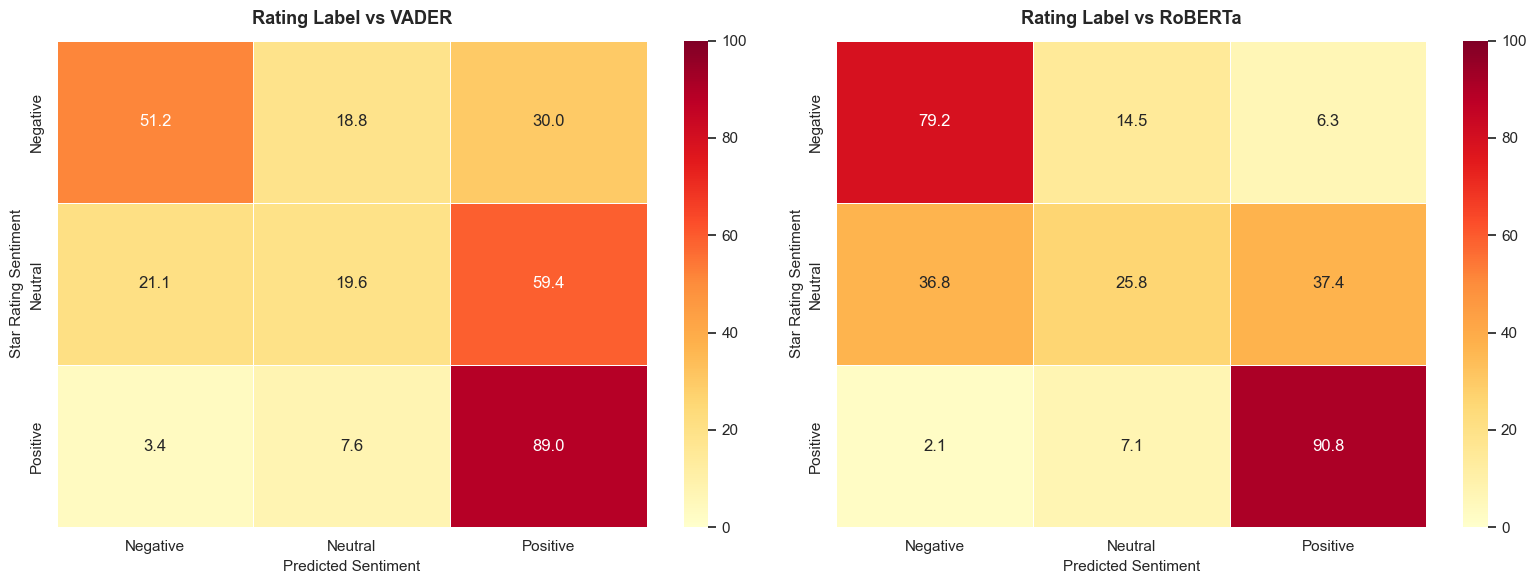

In [52]:
# STEP 12: Visualising Rating vs VADER vs RoBERTa side by side

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(
    axes,
    ["sentiment_label", "roberta_label"],
    ["Rating Label vs VADER", "Rating Label vs RoBERTa"]
):
    ct = pd.crosstab(df["rating_label"], df[col])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.reindex(
        index=["Negative", "Neutral", "Positive"],
        columns=["Negative", "Neutral", "Positive"],
        fill_value=0
    )
    sns.heatmap(
        ct_pct, annot=True, fmt=".1f", cmap="YlOrRd",
        linewidths=0.5, linecolor="white", ax=ax, vmin=0, vmax=100
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Sentiment", fontsize=11)
    ax.set_ylabel("Star Rating Sentiment", fontsize=11)

plt.tight_layout()
plt.savefig("chart_rating_vs_models.png", dpi=150, bbox_inches="tight")
plt.show()

The normalised heatmaps make the performance differences between VADER and RoBERTa immediately visible by expressing each row as a percentage, allowing a fair comparison regardless of class size.

- Negative reviews (1–2 stars):
The contrast here is striking. RoBERTa correctly identifies 79.2% of genuinely negative reviews, producing a strong dark red cell on the diagonal. VADER only manages 51.2%, and critically, misclassifies 30.0% of negative reviews as Positive — nearly one in three unhappy customers would be missed entirely. This is VADER's most significant weakness and is clearly visible in the lighter orange tone of its Negative diagonal compared to RoBERTa's deep red.

- Neutral reviews (3 stars):
Both heatmaps show weak diagonals here — confirming that 3-star reviews are the hardest to classify. VADER's most common prediction for neutral reviews is Positive (59.4%), showing a strong positive bias. RoBERTa distributes predictions more evenly across all three classes (36.8% Negative, 25.8% Neutral, 37.4% Positive), which, while still not accurate, at least reflects genuine uncertainty rather than a systematic bias in one direction.

- Positive reviews (4–5 stars):
Both models perform well, with RoBERTa slightly edging ahead at 90.8% correct versus VADER's 89.0%. The diagonal cells are the darkest in both heatmaps, confirming that Positive is by far the easiest class for both models to predict reliably.
Overall visual takeaway: RoBERTa's heatmap has a much cleaner and darker diagonal, particularly in the Negative row, indicating better alignment with star ratings across all sentiment classes. VADER's heatmap reveals a consistent positive bias — the top-right cell (Negative reviews predicted as Positive) being notably brighter than the same cell in RoBERTa's chart tells the whole story visually.


In [53]:
# STEP 13: Inspecting disagreement cases

disagreements = df[df["sentiment_label"] != df["roberta_label"]].copy()
print(f"Total disagreements: {len(disagreements):,} ({len(disagreements)/len(df)*100:.1f}% of reviews)\n")

print("Top disagreement patterns:")
print(
    disagreements.groupby(["sentiment_label", "roberta_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .to_string(index=False)
)

print("\n--- Sample disagreement cases ---")
sample_cols = ["reviews.text", "reviews.rating", "sentiment_label", "roberta_label", "roberta_confidence"]
print(disagreements[sample_cols].sample(5, random_state=42).to_string())

Total disagreements: 3,951 (14.0% of reviews)

Top disagreement patterns:
sentiment_label roberta_label  count
        Neutral      Positive   1040
       Positive       Neutral   1007
       Positive      Negative    729
       Negative      Positive    506
        Neutral      Negative    378
       Negative       Neutral    291

--- Sample disagreement cases ---
                                                                                                                                                                            reviews.text  reviews.rating sentiment_label roberta_label  roberta_confidence
21094  You can't do better for$60. My only concerns is the battery life could be a bit better and it has a cheap plastic feel to it. Great for light browsing and Kindle reading though.               4        Positive      Negative            0.515075
12296                                                      I added this to my echo collection great for on the go and around the h

Out of 28,262 reviews, 3,951 (14.0%) are classified differently by VADER and RoBERTa. While an 86% agreement rate is generally strong, examining these disagreements reveals systematic patterns rather than random noise.

Top disagreement patterns:
The two largest disagreement groups are almost mirror images of each other — Neutral→Positive (1,040) and Positive→Neutral (1,007) — meaning the boundary between Positive and Neutral is where both models are most uncertain. This is expected, as mildly positive language sits right at the threshold between the two classes. The more concerning patterns are Positive→Negative (729) and Negative→Positive (506), where the models reach completely opposite conclusions on the same review.

Sample case analysis:
The sampled disagreements are particularly revealing:

- "You can't do better for $60... battery life could be a bit better... cheap plastic feel... Great for light browsing" — VADER reads this as Positive (picking up "Great"), while RoBERTa flags it as Negative, likely detecting the criticism of battery life and build quality. The low RoBERTa confidence (0.51) suggests even the model is uncertain here.

- "absolute garbage... dies so quick... Not worth the money" — This 1-star review is rated Positive by VADER, which is a clear failure. The review contains words like "sorry" and phrases VADER may misread, while RoBERTa correctly identifies it as Negative with high confidence (0.93). This is exactly the type of error that would be costly in a real-world complaint detection system.

- "Good amount of battery for the price. But they are not as long lasting as Duracell" — VADER sees Positive, RoBERTa sees Neutral. The conjunction "But" signals a reservation that RoBERTa picks up contextually but VADER's word-scoring approach misses.

- "my third amazon fire, has more features... battery lasts longer" — Interestingly VADER labels this Negative while RoBERTa correctly reads it as Positive, showing that VADER can also misfire in the opposite direction.

***Key takeaway: The disagreement cases consistently show that VADER is tripped up by mixed-language reviews — those where criticism is wrapped in polite framing, or where a single strong positive word outweighs several negative ones. RoBERTa's contextual awareness handles these edge cases more reliably, though its lower confidence scores on many disagreements (0.41–0.52) confirm that these are genuinely ambiguous reviews where even a deep learning model is not certain.



RoBERTa sentiment (%) by category:
roberta_label    Positive  Neutral  Negative
category                                    
Electronics          84.8      6.8       8.4
Health & Beauty      78.6     14.3       7.1
Office Supplies      91.4      5.4       3.2
Toys & Games         88.9      5.4       5.7


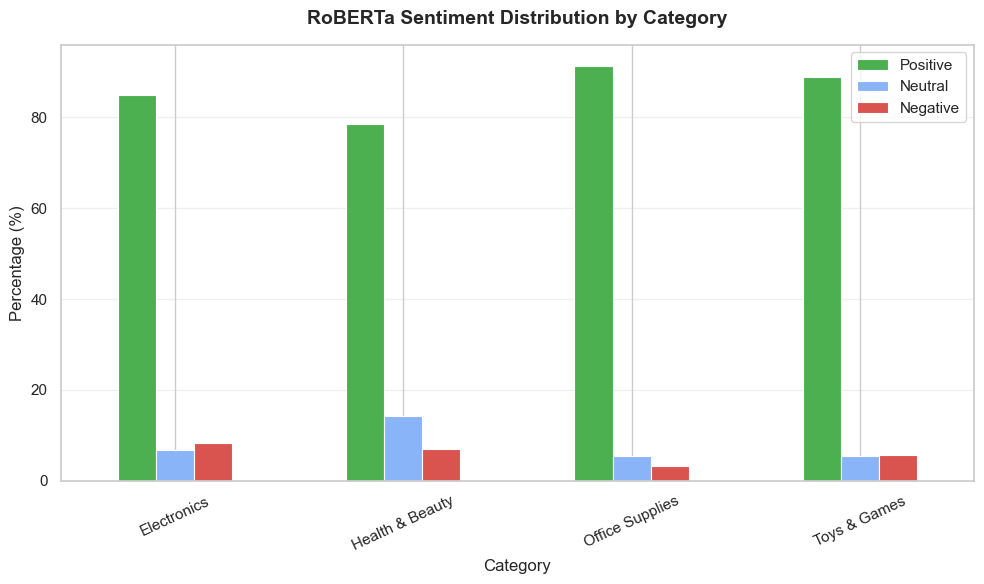

In [54]:
# STEP 14: RoBERTa sentiment distribution by product category

roberta_by_cat = (
    df.groupby(["category", "roberta_label"])
    .size()
    .unstack(fill_value=0)
)
roberta_by_cat_pct = roberta_by_cat.div(roberta_by_cat.sum(axis=1), axis=0) * 100

print("RoBERTa sentiment (%) by category:")
print(roberta_by_cat_pct[["Positive", "Neutral", "Negative"]].round(1))

roberta_by_cat_pct[["Positive", "Neutral", "Negative"]].plot(
    kind="bar", figsize=(10, 6),
    color=["#4CAF50", "#8ab4f8", "#d9534f"],
    edgecolor="white", linewidth=0.8
)
plt.title("RoBERTa Sentiment Distribution by Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=25)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("chart_roberta_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

Breaking down RoBERTa sentiment by product category reveals meaningful differences in customer satisfaction levels across Amazon's product range.

- Office Supplies emerges as the highest-rated category with 91.4% Positive sentiment and the lowest Negative rate of just 3.2%. This likely reflects that office products such as batteries and basic stationery have straightforward use cases with clear and easily met customer expectations — there is little room for disappointment when a product does exactly what it says.

- Toys & Games follows closely at 88.9% Positive and a moderate Negative rate of 5.7%. The relatively low Neutral score (5.4%) suggests customers tend to have strong opinions either way — toys either delight or disappoint, with less middle ground.

- Electronics sits at 84.8% Positive but carries the second highest Negative rate at 8.4% and a notably low Neutral rate of 6.8%. Electronics products tend to attract more critical reviews because customer expectations are higher and technical failures — such as battery life, connectivity, or build quality — are more easily identified and articulated. The sample disagreement cases in Step 13 also featured Electronics reviews prominently, confirming this pattern.

- Health & Beauty has the lowest Positive rate at 78.6% and the highest Neutral rate at 14.3%. This is an interesting finding — health and beauty products often produce more measured, conditional reviews ("works for some skin types but not others", "results vary") where customers acknowledge partial satisfaction rather than a clear positive or negative experience. This explains the elevated Neutral proportion compared to other categories.

***Key takeaway: Category context matters significantly when interpreting sentiment. A business monitoring product feedback should apply different benchmarks per category — an 84% Positive rate in Electronics may actually signal stronger performance than the same rate in Office Supplies, given the inherently higher complexity and expectation level of electronic products.

Sentiment Distribution Comparison (%):
          VADER  RoBERTa  Star Rating
Positive   84.5     83.8         90.2
Neutral     8.7      8.3          4.2
Negative    6.8      7.9          5.6


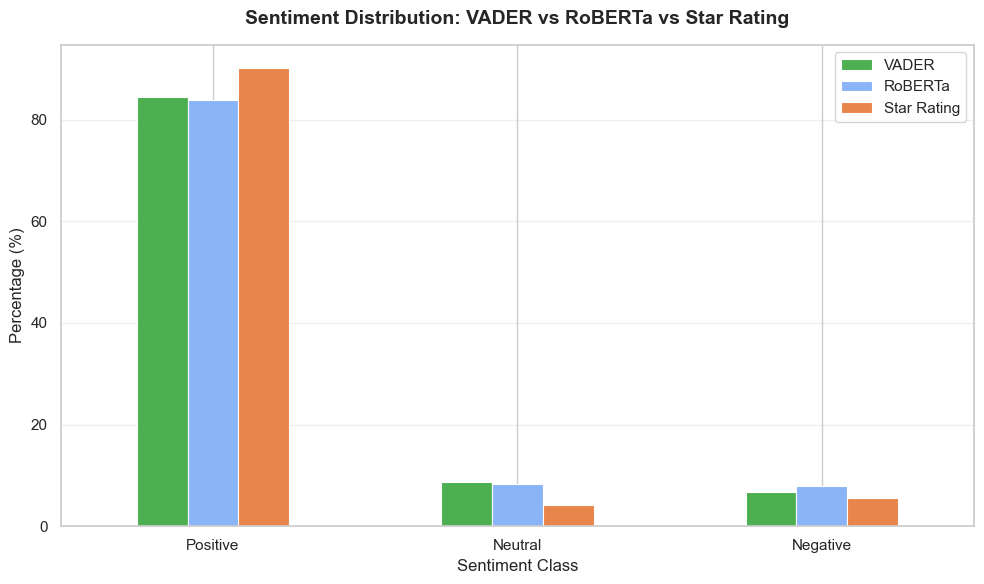

In [55]:
# STEP 15: Final comparison — all three sentiment sources

summary = pd.DataFrame({
    "VADER":       df["sentiment_label"].value_counts(normalize=True).mul(100).round(1),
    "RoBERTa":     df["roberta_label"].value_counts(normalize=True).mul(100).round(1),
    "Star Rating": df["rating_label"].value_counts(normalize=True).mul(100).round(1),
}).reindex(["Positive", "Neutral", "Negative"])

print("Sentiment Distribution Comparison (%):")
print(summary.to_string())

summary.plot(
    kind="bar", figsize=(10, 6),
    color=["#4CAF50", "#8ab4f8", "#e8854a"],
    edgecolor="white", linewidth=0.8
)
plt.title("Sentiment Distribution: VADER vs RoBERTa vs Star Rating",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Sentiment Class", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("chart_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Overall summary:

The final comparison table brings together all three sentiment measurement approaches and reveals both their consistency and their important differences.

Where all three methods agree:
All three sources confirm the same fundamental finding — Amazon product reviews are overwhelmingly Positive, ranging from 83.8% (RoBERTa) to 90.2% (Star Rating). This consistency across completely different measurement methods — a lexicon-based model, a deep learning model, and direct customer ratings — strongly validates the conclusion that Amazon's product range generally satisfies its customers.

Star Ratings vs the two NLP models:
Star ratings produce the most Positive distribution (90.2%) and the least Neutral (4.2%), which makes sense behaviourally — customers who bother to leave a rating tend to express a clear opinion, and the majority choose 4 or 5 stars. The 3-star "Neutral" rating is the least commonly used on Amazon, as customers tend to either recommend or not recommend a product. Both NLP models therefore capture more nuance by detecting mixed or ambiguous language that a simple star rating would round up to Positive.

VADER vs RoBERTa:
VADER and RoBERTa produce remarkably similar overall distributions — differing by less than 1 percentage point on Positive (84.5% vs 83.8%) and Neutral (8.7% vs 8.3%). However RoBERTa assigns slightly more reviews to Negative (7.9% vs 6.8%), which aligns with the earlier finding that RoBERTa is better at detecting dissatisfaction expressed in polite or indirect language that VADER tends to misread as Neutral or Positive. This 1.1 percentage point difference in Negative classification may seem small overall, but as Steps 11–13 demonstrated, it represents thousands of reviews where the models reach opposite conclusions.

Overall conclusion:
This analysis demonstrates that no single sentiment method tells the complete story. Star ratings are simple and direct but miss nuance. VADER is fast and interpretable but has a positive bias in ambiguous cases. RoBERTa is the most contextually aware and performs best on Negative and mixed reviews, making it the most reliable choice for actionable insights — particularly for complaint detection, product quality monitoring, or identifying at-risk customers. Used together, the three methods provide a more complete and trustworthy picture of customer sentiment than any one approach alone.